# OOBMeanPath real-data benchmark: DIF + SLAD

OOBMeanPath and the classical baselines run in the current Jupyter kernel. DIF and SLAD run in a dedicated Python 3.10 conda environment created and checked by this notebook, avoiding PyTorch/DeepOD conflicts in the current kernel.

All datasets use the same fixed 14-method set.


In [1]:
# Run the dedicated-environment setup cell below once.
# The first run can take several minutes because it creates a Python 3.10
# environment with CPU PyTorch 1.12.1 and DeepOD 0.4.1.


### Added baselines

- **DIF**: `pyod.models.dif.DIF`, run on CPU with its documented defaults except for the benchmark contamination and random seed.

The repeated matched-seed section remains intentionally limited to **OOBMeanPath vs. standard IForest**, because it is a robustness analysis of the proposed scoring change rather than a repeated benchmark of all baselines.


In [2]:

from __future__ import annotations

from pathlib import Path
import os
import sys
import shutil
import subprocess
import tempfile
import json
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy.io import loadmat, arff, savemat
from scipy import sparse as scipy_sparse
import h5py
import re
import math
from scipy.stats import (
  wilcoxon,
  binomtest,
  friedmanchisquare,
  rankdata,
  studentized_range,
)

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

EXPERIMENT_ID = "OOBMEANPATH_ALL_DATASETS_DIF_SLAD"

SEED = 20260813
N_ESTIMATORS = 100
OOB_FRAC = 0.80
CONTAMINATION = 0.10
MAX_FEATURES = 1.0

# Repeated matched-seed comparison. No best seed is selected.
N_REPEATS = 20
REPEAT_SEEDS = [
  SEED + 10000 + 997 * r
  for r in range(N_REPEATS)
]

N_BOOTSTRAP = 20000
BOOTSTRAP_SEED = SEED + 54321

RUN_BASELINES = True

# Put the notebook and all .arff/.mat files in this folder,
# or change DATA_DIR to the folder that contains the datasets.
DATA_DIR = Path.cwd()

OUTPUT_DIR = (
  DATA_DIR
  / "oobmeanpath_all_dataset_outputs"
)
OUTPUT_DIR.mkdir(
  parents=True,
  exist_ok=True,
)

# Dedicated environment for DIF and SLAD.
DEEP_ENV_NAME = "oobmeanpath_deep310"
DEEP_PYTHON_VERSION = "3.10"
DEEPOD_VERSION = "0.4.1"
PYTORCH_VERSION = "1.12.1"
DEEP_ENV_READY = False
DEEP_WORKER_PATH = OUTPUT_DIR / "_deep_baseline_worker.py"

BASELINES = [
  "IForest",
  "DIF",
  "SLAD",
  "ECOD",
  "KNN",
  "COPOD",
  "HBOS",
  "OCSVM",
  "CBLOF",
  "LODA",
  "ABOD",
  "LOF",
  "FeatureBagging",
]

PROPOSED = "OOBMeanPath"
METHODS = [PROPOSED] + BASELINES
N_METHODS = len(METHODS)


FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_CANDIDATES = (
  "y",
  "label",
  "labels",
  "class",
  "target",
  "outlier",
  "anomaly",
  "ground_truth",
  "groundtruth",
  "gt",
  "is_anomaly",
  "isanomaly",
  "anomaly_label",
  "anomalylabel",
  "outlier_label",
  "outlierlabel",
  "outcome",
  "diagnosis",
  "recurrence",
  "recurrence_status",
  "recurrencestatus",
  "status",
  "result",
  "response",
  "class_label",
  "classlabel",
)

# Known source-specific label rules. These rules are applied BEFORE
# generic multiclass fallbacks and are recorded in loader_audit.csv.
DATASET_LABEL_RULES = {
  "arrhythmia.arff": {
    "mode": "normal_vs_rest",
    "normal_values": {"1"},
    "note": "UCI Arrhythmia: class 1 treated as normal; other classes as abnormal.",
  },
  "shuttle.arff": {
    "mode": "normal_vs_rest",
    "normal_values": {"1"},
    "note": "UCI Shuttle: class 1 treated as normal; other classes as abnormal.",
  },
  "waveform-5000.arff": {
    "mode": "minority_vs_rest",
    "note": (
      "Waveform is natively multiclass, not a canonical anomaly benchmark. "
      "The rarest class is binarized as anomaly ONLY to make the file technically analyzable; "
      "do not include it in the selected benchmark without an externally justified anomaly definition."
    ),
  },
  "wpbc.arff": {
    "mode": "semantic_binary",
    "anomaly_values": {"r", "recurrence", "recurrent", "yes", "1"},
    "normal_values": {"n", "non-recurrence", "nonrecurrence", "no", "0"},
    "note": "WPBC recurrence outcome treated as the anomaly class.",
  },
  "wdbc.arff": {
    "mode": "binary_minority",
    "note": "WDBC minority diagnosis is treated as anomaly; avoids assuming numeric value 1 is anomalous.",
  },
  "ecoli.mat": {
    "mode": "binary_minority",
    "note": "Binary Ecoli benchmark: minority class treated as anomaly after robust MAT label search.",
  },
}

# Generic multiclass fallback is deterministic so every labeled file can
# be analyzed. It is logged because such a conversion may not be a
# scientifically canonical anomaly-detection benchmark.
MULTICLASS_FALLBACK = "minority_vs_rest"
STRICT_PREFLIGHT = True

print("EXPERIMENT:", EXPERIMENT_ID)
print("Proposed method:", PROPOSED)
print("Baselines:", len(BASELINES), BASELINES)
print("Total methods:", N_METHODS)
print("Data folder:", DATA_DIR.resolve())
print("No cross-fitting or folds.")
print("Matched-seed repetitions:", N_REPEATS)
print("Output:", OUTPUT_DIR.resolve())


EXPERIMENT: OOBMEANPATH_ALL_DATASETS_DIF_SLAD
Proposed method: OOBMeanPath
Baselines: 13 ['IForest', 'DIF', 'SLAD', 'ECOD', 'KNN', 'COPOD', 'HBOS', 'OCSVM', 'CBLOF', 'LODA', 'ABOD', 'LOF', 'FeatureBagging']
Total methods: 14
Data folder: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Datasets and Code 4 (30 datasets)
No cross-fitting or folds.
Matched-seed repetitions: 20
Output: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Datasets and Code 4 (30 datasets)\oobmeanpath_all_dataset_outputs


In [3]:
# -------------------------------------------------------------------------
# Dedicated DIF/SLAD environment setup
# -------------------------------------------------------------------------
# DeepOD 0.4.1 supports Python through 3.10 and declares
# torch >=1.10.0,<1.13.1.
#
# Windows note:
# conda.BAT can interpret '<' and '>' in pip requirement strings as shell
# redirection. To avoid that problem, this notebook:
#
#   1) uses conda only to create the Python 3.10 environment and install
#      CPU PyTorch 1.12.1;
#   2) locates the environment's own python.exe;
#   3) runs pip directly through that python.exe;
#   4) uses exact dependency versions; and
#   5) installs DeepOD with --no-deps after the dependencies are pinned.

def _run_cmd(cmd, check=True, capture=True):
    cmd = [str(x) for x in cmd]

    print("$", " ".join(cmd))

    result = subprocess.run(
        cmd,
        text=True,
        stdout=subprocess.PIPE if capture else None,
        stderr=subprocess.STDOUT if capture else None,
    )

    if capture and result.stdout:
        print(result.stdout)

    if check and result.returncode != 0:
        raise RuntimeError(
            "Command failed with exit code "
            f"{result.returncode}: {' '.join(cmd)}\n"
            + (result.stdout or "")
        )

    return result


def _find_conda():
    candidates = [
        os.environ.get("CONDA_EXE"),
        shutil.which("conda"),
        shutil.which("conda.exe"),
        str(Path.home() / "AppData/Local/anaconda3/Scripts/conda.exe"),
        str(Path.home() / "AppData/Local/anaconda3/Library/bin/conda.bat"),
        str(Path.home() / "anaconda3/Scripts/conda.exe"),
        str(Path.home() / "miniconda3/Scripts/conda.exe"),
    ]

    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return str(Path(candidate))

    raise RuntimeError(
        "Could not locate conda. Anaconda or Miniconda is required "
        "for the isolated DIF/SLAD environment."
    )


def _parse_conda_json(text):
    start = text.find("{")
    end = text.rfind("}")

    if start < 0 or end < start:
        raise RuntimeError(
            "Could not parse conda JSON output:\n" + text
        )

    return json.loads(text[start:end + 1])


def _find_deep_python():
    result = _run_cmd(
        [
            CONDA_EXE,
            "env",
            "list",
            "--json",
        ],
        check=True,
        capture=True,
    )

    info = _parse_conda_json(
        result.stdout or ""
    )

    for prefix in info.get("envs", []):
        prefix_path = Path(prefix)

        if prefix_path.name.lower() == DEEP_ENV_NAME.lower():
            if os.name == "nt":
                python_path = prefix_path / "python.exe"
            else:
                python_path = prefix_path / "bin" / "python"

            if python_path.exists():
                return str(python_path)

    return None


CONDA_EXE = _find_conda()

print("Using conda:", CONDA_EXE)


DEEP_SMOKE_CODE = r"""
import numpy as np
import torch
from deepod.models.tabular import DeepIsolationForest, SLAD

print("torch:", torch.__version__)

X = np.random.RandomState(42).normal(
    size=(60, 8)
).astype("float32")

dif = DeepIsolationForest(
    n_ensemble=2,
    n_estimators=2,
    max_samples=32,
    device="cpu",
    verbose=0,
    random_state=42,
)

dif.fit(X)

s1 = np.asarray(
    dif.decision_function(X),
    dtype=float,
).reshape(-1)

assert len(s1) == len(X)
assert np.isfinite(s1).all()

slad = SLAD(
    epochs=1,
    batch_size=32,
    hidden_dims=16,
    distribution_size=4,
    n_slad_ensemble=2,
    subspace_pool_size=4,
    n_unified_features=16,
    device="cpu",
    verbose=0,
    random_state=42,
)

slad.fit(X)

s2 = np.asarray(
    slad.decision_function(X),
    dtype=float,
).reshape(-1)

assert len(s2) == len(X)
assert np.isfinite(s2).all()

print("DIF + SLAD smoke test passed")
"""


def _deep_env_is_ready(python_exe):
    if not python_exe:
        return False

    result = _run_cmd(
        [
            python_exe,
            "-c",
            DEEP_SMOKE_CODE,
        ],
        check=False,
        capture=True,
    )

    return result.returncode == 0


DEEP_PYTHON_EXE = _find_deep_python()

if not _deep_env_is_ready(DEEP_PYTHON_EXE):
    print(
        "\nThe dedicated DIF/SLAD environment is missing or incompatible. "
        "Rebuilding it now...\n"
    )

    env_list = _run_cmd(
        [
            CONDA_EXE,
            "env",
            "list",
        ],
        check=True,
        capture=True,
    ).stdout or ""

    if DEEP_ENV_NAME in env_list:
        _run_cmd(
            [
                CONDA_EXE,
                "env",
                "remove",
                "-n",
                DEEP_ENV_NAME,
                "-y",
            ],
            check=True,
            capture=True,
        )

    _run_cmd(
        [
            CONDA_EXE,
            "create",
            "-n",
            DEEP_ENV_NAME,
            f"python={DEEP_PYTHON_VERSION}",
            "pip",
            "-y",
        ],
        check=True,
        capture=True,
    )

    _run_cmd(
        [
            CONDA_EXE,
            "install",
            "-n",
            DEEP_ENV_NAME,
            f"pytorch={PYTORCH_VERSION}",
            "cpuonly",
            "-c",
            "pytorch",
            "-y",
        ],
        check=True,
        capture=True,
    )

    DEEP_PYTHON_EXE = _find_deep_python()

    if not DEEP_PYTHON_EXE:
        raise RuntimeError(
            "The helper environment was created, but its Python "
            "executable could not be located."
        )

    print(
        "Dedicated Python:",
        DEEP_PYTHON_EXE,
    )

    _run_cmd(
        [
            DEEP_PYTHON_EXE,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "pip",
            "setuptools",
            "wheel",
        ],
        check=True,
        capture=True,
    )

    pinned_dependencies = [
        "numpy==1.23.5",
        "scipy==1.10.1",
        "scikit-learn==1.3.2",
        "pandas==2.0.3",
        "tqdm==4.66.1",
        "ray==2.6.1",
        "pyarrow==12.0.1",
        "einops==0.7.0",
        "statsmodels==0.14.1",
        "arch==6.3.0",
    ]

    _run_cmd(
        [
            DEEP_PYTHON_EXE,
            "-m",
            "pip",
            "install",
            "--no-cache-dir",
            *pinned_dependencies,
        ],
        check=True,
        capture=True,
    )

    _run_cmd(
        [
            DEEP_PYTHON_EXE,
            "-m",
            "pip",
            "install",
            "--no-cache-dir",
            "--no-deps",
            f"deepod=={DEEPOD_VERSION}",
        ],
        check=True,
        capture=True,
    )

    if not _deep_env_is_ready(DEEP_PYTHON_EXE):
        raise RuntimeError(
            "The dedicated DIF/SLAD environment was rebuilt, but "
            "its smoke test still failed. Review the installation "
            "output immediately above."
        )

else:
    print(
        "Existing dedicated DIF/SLAD environment passed the smoke test."
    )


DEEP_ENV_READY = True

print(
    "\nDedicated DIF/SLAD environment is ready."
)
print(
    "Dedicated Python:",
    DEEP_PYTHON_EXE,
)


# -------------------------------------------------------------------------
# Worker used for DIF and SLAD on every real dataset
# -------------------------------------------------------------------------
DEEP_WORKER_SOURCE = r"""
import argparse
import time

import numpy as np
import torch

from deepod.models.tabular import DeepIsolationForest, SLAD


def sanitize(scores):
    scores = np.asarray(
        scores,
        dtype=float,
    ).reshape(-1)

    finite = np.isfinite(scores)

    if not finite.any():
        raise RuntimeError(
            "Model returned no finite anomaly scores."
        )

    hi = float(
        np.max(scores[finite])
    )
    lo = float(
        np.min(scores[finite])
    )

    return np.nan_to_num(
        scores,
        nan=0.0,
        posinf=hi,
        neginf=lo,
    )


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--method",
        required=True,
        choices=["DIF", "SLAD"],
    )
    parser.add_argument(
        "--input",
        required=True,
    )
    parser.add_argument(
        "--output",
        required=True,
    )
    parser.add_argument(
        "--seed",
        type=int,
        required=True,
    )

    args = parser.parse_args()

    X = np.asarray(
        np.load(args.input),
        dtype=np.float32,
    )

    seed = int(args.seed)

    np.random.seed(seed)
    torch.manual_seed(seed)

    if args.method == "DIF":
        model = DeepIsolationForest(
            n_ensemble=50,
            n_estimators=6,
            max_samples=min(256, len(X)),
            device="cpu",
            verbose=0,
            random_state=seed,
        )

    else:
        model = SLAD(
            epochs=100,
            batch_size=128,
            lr=0.001,
            hidden_dims=100,
            act="LeakyReLU",
            distribution_size=10,
            n_slad_ensemble=20,
            subspace_pool_size=50,
            magnify_factor=200,
            n_unified_features=128,
            epoch_steps=-1,
            prt_steps=10,
            device="cpu",
            verbose=0,
            random_state=seed,
        )

    t0 = time.perf_counter()

    model.fit(X)

    scores = sanitize(
        model.decision_function(X)
    )

    elapsed = time.perf_counter() - t0

    if len(scores) != len(X):
        raise RuntimeError(
            f"{args.method}: returned {len(scores)} scores "
            f"for {len(X)} observations."
        )

    np.savez_compressed(
        args.output,
        scores=scores,
        runtime_sec=np.asarray(
            [elapsed],
            dtype=float,
        ),
    )


if __name__ == "__main__":
    main()
"""

DEEP_WORKER_PATH.write_text(
    DEEP_WORKER_SOURCE,
    encoding="utf-8",
)

print(
    "Deep worker:",
    DEEP_WORKER_PATH,
)


Using conda: C:\Users\jzhou\AppData\Local\anaconda3\Library\bin\conda.BAT
$ C:\Users\jzhou\AppData\Local\anaconda3\Library\bin\conda.BAT env list --json
{
  "active_prefix": "C:\\Users\\jzhou\\AppData\\Local\\anaconda3",
  "active_prefix_name": "base",
  "av_data_dir": "C:\\Users\\jzhou\\AppData\\Local\\anaconda3\\etc\\conda",
  "av_metadata_url_base": null,
  "channels": [
    "https://repo.anaconda.com/pkgs/main/win-64",
    "https://repo.anaconda.com/pkgs/main/noarch",
    "https://repo.anaconda.com/pkgs/r/win-64",
    "https://repo.anaconda.com/pkgs/r/noarch",
    "https://repo.anaconda.com/pkgs/msys2/win-64",
    "https://repo.anaconda.com/pkgs/msys2/noarch"
  ],
  "conda_build_version": "24.5.1",
  "conda_env_version": "24.7.1",
  "conda_location": "C:\\Users\\jzhou\\AppData\\Local\\anaconda3\\Lib\\site-packages\\conda",
  "conda_prefix": "C:\\Users\\jzhou\\AppData\\Local\\anaconda3",
  "conda_shlvl": -1,
  "conda_version": "24.7.1",
  "config_files": [
    "C:\\Users\\jzhou\\.co


## Automatic dataset discovery, robust loading, and path-length utilities

The loader is used here for `.arff` and `.mat` files.

Key safeguards:
- target-column inference uses expanded semantic names (`outcome`, `diagnosis`, `recurrence`, `gt`, etc.);
- MATLAB label selection jointly matches feature matrices and non-single-class label vectors;
- multiclass sources are deterministically binarized and **flagged** in `loader_audit.csv`;
- MATLAB v7.3/HDF5 and sparse arrays are supported;
- rows with missing labels, all-missing features, and constant features are handled explicitly;
- a preflight pass validates **every discovered file before the expensive benchmark begins**.

Any dataset with a nonempty `label_warning` should be manually checked against its source definition.


In [4]:

def _decode_obj(v):
  return v.decode("utf-8", errors="ignore") if isinstance(v, (bytes, bytearray)) else v


def _norm_name(x):
  return re.sub(r"[^a-z0-9]+", "", str(x).strip().lower())


def _canon_label_text(v):
  """Canonical label token so 1, 1.0, '1', b'1', and '1.0' match."""
  v = _decode_obj(v)
  s = str(v).strip().lower()
  if s in {"", "?", "nan", "none", "null", "na", "n/a"}:
    return s
  try:
    z = float(s)
    if np.isfinite(z):
      if float(z).is_integer():
        return str(int(z))
      return format(float(z), ".15g")
  except Exception:
    pass
  return s


_LABEL_NAME_KEYS = {_norm_name(x) for x in LABEL_CANDIDATES}

_ANOMALY_WORDS = {
  "1", "yes", "y", "true", "outlier", "anomaly", "anomalous",
  "positive", "pos", "abnormal", "attack", "malignant", "m",
  "recurrence", "recurrent", "r",
}
_NORMAL_WORDS = {
  "0", "no", "n", "false", "normal", "inlier", "negative", "neg",
  "benign", "b", "non-recurrence", "nonrecurrence", "nonrecurrent",
}


def _to_dense(a):
  if scipy_sparse.issparse(a):
    return a.toarray()
  return np.asarray(a)


def _to_vector(a):
  a = _to_dense(a)
  a = np.asarray(a)
  a = np.squeeze(a)
  if a.ndim == 1:
    return a
  # Treat 1 x n / n x 1 as vectors after squeeze; other matrices are not vectors.
  return None


def _label_missing_mask(y):
  a = np.asarray(y).reshape(-1)
  vals = np.array([_canon_label_text(v) for v in a], dtype=object)
  return np.array([v in {"", "?", "nan", "none", "null", "na", "n/a"} for v in vals], dtype=bool)


def _raw_label_values(y):
  a = np.asarray(y).reshape(-1)
  canon = np.array([_canon_label_text(v) for v in a], dtype=object)
  numeric = pd.to_numeric(pd.Series(canon), errors="coerce").to_numpy()
  if np.isfinite(numeric).all():
    return numeric
  return canon


def _rule_for(path):
  return DATASET_LABEL_RULES.get(Path(path).name.lower(), {})


def normalize_labels(y, dataset_name=None, return_meta=False):
  """
  Convert a source label vector to {0,1}.

  Important:
  - source-specific rules are applied first;
  - binary semantic labels are resolved from their meaning when possible;
  - generic binary {0,1} keeps 1 as anomaly for backward compatibility;
  - unresolved multiclass files are deterministically collapsed and FLAGGED.
  """
  raw = np.asarray(y).reshape(-1)
  miss = _label_missing_mask(raw)
  if miss.any():
    raise ValueError(
      f"Label vector still contains {int(miss.sum())} missing values. "
      "The loader should remove these rows before normalize_labels()."
    )

  vals = _raw_label_values(raw)
  uniq, counts = np.unique(vals, return_counts=True)
  if len(uniq) < 2:
    raise ValueError(f"Expected at least two label classes, found {uniq.tolist()}")

  name = str(dataset_name or "").lower()
  rule = DATASET_LABEL_RULES.get(name, {})
  mode = rule.get("mode")
  warning = ""
  positive_values = None

  def _as_text_set(items):
    return {_canon_label_text(v) for v in items}

  # For string-like values, keep a parallel normalized text representation.
  txt_vals = np.array([_canon_label_text(v) for v in vals], dtype=object)
  txt_uniq = np.unique(txt_vals)

  if mode == "normal_vs_rest":
    normals = _as_text_set(rule.get("normal_values", set()))
    ybin = np.array([0 if _canon_label_text(v) in normals else 1 for v in txt_vals], dtype=int)
    positive_values = [u for u in uniq if _canon_label_text(u) not in normals]
    resolution = "source_rule:normal_vs_rest"

  elif mode == "semantic_binary":
    anomalies = _as_text_set(rule.get("anomaly_values", set()))
    normals = _as_text_set(rule.get("normal_values", set()))
    observed = set(txt_uniq.tolist())
    if observed & anomalies:
      ybin = np.array([1 if v in anomalies else 0 for v in txt_vals], dtype=int)
      positive_values = [u for u in uniq if _canon_label_text(u) in anomalies]
      resolution = "source_rule:semantic_binary"
    elif observed & normals and len(uniq) == 2:
      ybin = np.array([0 if v in normals else 1 for v in txt_vals], dtype=int)
      positive_values = [u for u in uniq if _canon_label_text(u) not in normals]
      resolution = "source_rule:semantic_binary_complement"
    else:
      # Safe deterministic fallback for an unexpected encoding.
      pos = uniq[np.argmin(counts)]
      ybin = (vals == pos).astype(int)
      positive_values = [pos]
      resolution = "source_rule:fallback_minority"
      warning = "Expected semantic labels were not found; minority class was used."

  elif mode == "binary_minority":
    pos = uniq[np.argmin(counts)]
    ybin = (vals == pos).astype(int)
    positive_values = [pos]
    if len(uniq) == 2:
      resolution = "source_rule:binary_minority"
    else:
      resolution = "source_rule:binary_minority_fallback_multiclass"
      warning = (
        f"Dataset rule expected binary labels but found {uniq.tolist()}; "
        "the rarest class was used as anomaly. Verify before final analysis."
      )

  elif mode == "minority_vs_rest":
    pos = uniq[np.argmin(counts)]
    ybin = (vals == pos).astype(int)
    positive_values = [pos]
    resolution = "source_rule:minority_vs_rest"
    warning = rule.get("note", "")

  elif len(uniq) == 2:
    observed_text = set(txt_uniq.tolist())
    anomaly_hits = observed_text & _ANOMALY_WORDS
    normal_hits = observed_text & _NORMAL_WORDS

    if anomaly_hits and not (normal_hits and len(anomaly_hits) > 1):
      pos_txt = sorted(anomaly_hits)[0]
      ybin = (txt_vals == pos_txt).astype(int)
      positive_values = [u for u in uniq if _canon_label_text(u) == pos_txt]
      resolution = "semantic_binary:anomaly_word"

    elif normal_hits:
      normal_txt = sorted(normal_hits)[0]
      ybin = (txt_vals != normal_txt).astype(int)
      positive_values = [u for u in uniq if _canon_label_text(u) != normal_txt]
      resolution = "semantic_binary:normal_word_complement"

    elif np.issubdtype(np.asarray(vals).dtype, np.number) and set(np.asarray(uniq).tolist()) == {0, 1}:
      # Preserve the standard anomaly-benchmark convention unless a source rule overrides it.
      ybin = (np.asarray(vals) == 1).astype(int)
      positive_values = [1]
      resolution = "binary_01:value_1"

    else:
      pos = uniq[np.argmin(counts)]
      ybin = (vals == pos).astype(int)
      positive_values = [pos]
      resolution = "binary:minority"

  else:
    # Generic multiclass fallback. This makes the file analyzable but is
    # deliberately flagged so it cannot silently become a final analysis benchmark.
    if MULTICLASS_FALLBACK == "majority_vs_rest":
      normal = uniq[np.argmax(counts)]
      ybin = (vals != normal).astype(int)
      positive_values = [u for u in uniq if u != normal]
      resolution = "multiclass_fallback:majority_vs_rest"
    else:
      pos = uniq[np.argmin(counts)]
      ybin = (vals == pos).astype(int)
      positive_values = [pos]
      resolution = "multiclass_fallback:minority_vs_rest"

    warning = (
      f"Multiclass source labels {uniq.tolist()} were automatically collapsed by "
      f"{MULTICLASS_FALLBACK}. Verify this anomaly definition before final analysis."
    )

  if len(np.unique(ybin)) != 2:
    raise ValueError(
      f"Label conversion produced only one class for {dataset_name}: "
      f"raw={uniq.tolist()}, positive={positive_values}"
    )

  meta = {
    "raw_label_classes": repr(uniq.tolist()),
    "raw_label_counts": repr(counts.tolist()),
    "positive_raw_values": repr([str(v) for v in (positive_values or [])]),
    "label_resolution": resolution,
    "label_warning": warning or rule.get("note", ""),
  }

  return (ybin, meta) if return_meta else ybin


def _read_hdf5_mat(path):
  """
  Minimal MATLAB v7.3/HDF5 fallback. Top-level numeric datasets are sufficient
  for the common anomaly benchmark files (X + y/gt/label).
  """
  out = {}
  with h5py.File(path, "r") as f:
    def visitor(name, obj):
      if isinstance(obj, h5py.Dataset):
        try:
          arr = np.array(obj)
          if np.issubdtype(arr.dtype, np.number):
            out[name.split("/")[-1]] = arr
        except Exception:
          pass
    f.visititems(visitor)
  if not out:
    raise ValueError("No readable numeric datasets in MATLAB v7.3 file.")
  return out



def _load_mat_object(path):
  """
  Load MATLAB files with cell/struct simplification when possible.

  scipy.io.loadmat(..., simplify_cells=True) converts many MATLAB structs and
  cell arrays into ordinary Python dictionaries/lists. We still keep a
  recursive walker below because not every MAT file simplifies to a flat dict.
  """
  try:
    try:
      return loadmat(path, simplify_cells=True)
    except TypeError:
      # Compatibility with older scipy versions.
      return loadmat(path, squeeze_me=True, struct_as_record=False)
  except NotImplementedError:
    return _read_hdf5_mat(path)
  except ValueError as e:
    if "7.3" in str(e).lower() or "hdf" in str(e).lower():
      return _read_hdf5_mat(path)
    raise


def _walk_mat_leaves(obj, prefix=""):
  """
  Recursively yield (path, leaf) from MATLAB/Python containers.

  Handles:
   - dictionaries created by simplify_cells=True
   - scipy matlab_struct-like objects
   - numpy structured arrays / records
   - object/cell arrays
   - Python lists/tuples
   - ordinary numeric/string ndarrays
  """
  # Dictionary / simplified MATLAB struct
  if isinstance(obj, dict):
    for k, v in obj.items():
      if str(k).startswith("__"):
        continue
      p = f"{prefix}.{k}" if prefix else str(k)
      yield from _walk_mat_leaves(v, p)
    return

  # scipy mat_struct-like object
  fields = getattr(obj, "_fieldnames", None)
  if fields:
    for k in fields:
      try:
        v = getattr(obj, k)
      except Exception:
        continue
      p = f"{prefix}.{k}" if prefix else str(k)
      yield from _walk_mat_leaves(v, p)
    return

  # numpy structured scalar/array
  if isinstance(obj, np.void) and obj.dtype.names:
    for k in obj.dtype.names:
      p = f"{prefix}.{k}" if prefix else str(k)
      yield from _walk_mat_leaves(obj[k], p)
    return

  if isinstance(obj, np.ndarray) and obj.dtype.names:
    # Usually a 1x1 struct array; recurse over each structured element.
    flat = obj.reshape(-1)
    for j, item in enumerate(flat):
      p = f"{prefix}[{j}]" if len(flat) > 1 else prefix
      yield from _walk_mat_leaves(item, p)
    return

  # MATLAB cell array / generic object array.
  if isinstance(obj, np.ndarray) and obj.dtype == object:
    flat = obj.reshape(-1)
    # A 1-element cell is just a wrapper.
    if len(flat) == 1:
      yield from _walk_mat_leaves(flat[0], prefix)
    else:
      for j, item in enumerate(flat):
        p = f"{prefix}[{j}]"
        yield from _walk_mat_leaves(item, p)
    return

  if isinstance(obj, (list, tuple)):
    for j, item in enumerate(obj):
      p = f"{prefix}[{j}]"
      yield from _walk_mat_leaves(item, p)
    return

  # Leaf.
  yield prefix or "<root>", obj


def _leaf_array(v):
  """Convert a MAT leaf to an ndarray when meaningful."""
  try:
    if scipy_sparse.issparse(v):
      return v.toarray()
  except Exception:
    pass

  try:
    a = np.asarray(v)
  except Exception:
    return None

  # Ignore scalar metadata/string wrappers as feature/label candidates.
  if a.ndim == 0:
    return a
  return a


def _mat_vector_candidates(obj):
  candidates = []

  for key, value in _walk_mat_leaves(obj):
    arr = _leaf_array(value)
    if arr is None:
      continue

    # Standard vector candidate: n, n×1, or 1×n.
    vec = _to_vector(arr)
    if vec is not None and len(vec) >= 3:
      miss = _label_missing_mask(vec)
      clean = np.asarray(vec)[~miss]

      if len(clean) >= 3:
        try:
          vals = _raw_label_values(clean)
          nuniq = len(np.unique(vals))
        except Exception:
          nuniq = 999999

        if 2 <= nuniq <= min(100, len(clean)):
          score = 0
          leaf_name = key.split(".")[-1].split("[")[0]
          nk = _norm_name(leaf_name)

          if nk in _LABEL_NAME_KEYS:
            score += 1500
          if nk in {"y", "labels", "label", "class", "target",
               "outlier", "outliers", "anomaly", "anomalies",
               "groundtruth", "gt"}:
            score += 1000
          if nuniq == 2:
            score += 500
          elif nuniq <= 20:
            score += 150
          score -= nuniq

          candidates.append((score, str(key), np.asarray(vec)))
      continue

    # One-hot / indicator labels.
    if isinstance(arr, np.ndarray) and arr.ndim == 2 and min(arr.shape) >= 2 and min(arr.shape) <= 100:
      try:
        num = np.asarray(arr, dtype=float)
        finite = num[np.isfinite(num)]
        if finite.size and set(np.unique(finite).tolist()).issubset({0.0, 1.0}):
          leaf_name = key.split(".")[-1].split("[")[0]
          named_bonus = 700 if _norm_name(leaf_name) in _LABEL_NAME_KEYS else 0

          if num.shape[1] <= 100 and np.allclose(np.nansum(num, axis=1), 1):
            vec = np.argmax(num, axis=1)
            candidates.append(
              (900 + named_bonus, str(key) + "[onehot_rows]", vec)
            )
          elif num.shape[0] <= 100 and np.allclose(np.nansum(num, axis=0), 1):
            vec = np.argmax(num, axis=0)
            candidates.append(
              (900 + named_bonus, str(key) + "[onehot_cols]", vec)
            )
      except Exception:
        pass

  return candidates


def _mat_matrix_candidates(obj):
  mats = []
  preferred = {
    _norm_name(x)
    for x in (
      "X", "x", "data", "Data", "features", "Features",
      "observations", "samples", "xTrain", "Xtrain"
    )
  }

  for key, value in _walk_mat_leaves(obj):
    arr = _leaf_array(value)
    if arr is None:
      continue

    try:
      numeric = np.issubdtype(arr.dtype, np.number)
    except Exception:
      numeric = False

    if (
      isinstance(arr, np.ndarray)
      and arr.ndim == 2
      and min(arr.shape) > 1
      and numeric
    ):
      score = math.log1p(arr.size)
      leaf_name = key.split(".")[-1].split("[")[0]
      nk = _norm_name(leaf_name)

      if nk in preferred:
        score += 1500
      if nk in {"x", "data", "features", "observations", "samples",
           "xtrain", "trainx"}:
        score += 700

      mats.append((score, str(key), arr))

  return mats


def _mat_inventory(obj):
  """
  Human-readable recursive inventory used only when a MAT file fails.
  This makes a future failure self-diagnosing.
  """
  rows = []
  for key, value in _walk_mat_leaves(obj):
    arr = _leaf_array(value)
    if arr is None:
      rows.append((key, type(value).__name__, "", "", ""))
      continue

    try:
      dtype = str(arr.dtype)
    except Exception:
      dtype = type(value).__name__

    shape = tuple(arr.shape) if hasattr(arr, "shape") else ()
    nunique = ""
    preview = ""
    try:
      if arr.size <= 100000:
        flat = np.asarray(arr).reshape(-1)
        preview = repr(flat[:8].tolist())
        if flat.size:
          nunique = len(np.unique(flat))
    except Exception:
      pass

    rows.append((key, type(value).__name__, str(shape), dtype, nunique, preview))

  return pd.DataFrame(
    rows,
    columns=["mat_path", "python_type", "shape", "dtype", "n_unique", "preview"],
  )



def _ecoli_source_repair(path, return_meta=False):
  """
  Repair the known corrupted Ecoli MAT benchmark.

  The corrupted file observed in this project contains:
   X: shape (336, 7), but all entries are NaN
   y: shape (336,), but all entries are 0

  That file cannot be evaluated. This fallback reconstructs the canonical
  336 x 7 Ecoli anomaly benchmark from the original UCI Ecoli data.

  Following the anomaly-detection construction used by Sathe & Aggarwal
  (LODES), the minority localization classes omL, imL, and imS are treated
  as outliers; all other classes are inliers. This yields exactly 9 outliers.
  """
  urls = [
    "https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data",
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/ecoli.data",
    "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/ecoli.data",
  ]

  last_error = None
  df = None
  used_url = None

  for url in urls:
    try:
      df_try = pd.read_csv(
        url,
        sep=r"\s+",
        header=None,
        engine="python",
      )
      if df_try.shape == (336, 9):
        df = df_try
        used_url = url
        break
      last_error = ValueError(
        f"Downloaded Ecoli table had shape {df_try.shape}, expected (336, 9)"
      )
    except Exception as e:
      last_error = e

  if df is None:
    raise RuntimeError(
      "ecoli.mat is corrupted (all-NaN X / single-class y), and the notebook "
      "could not download the canonical UCI Ecoli source automatically. "
      "Internet access is required for this one-time repair. "
      f"Last download error: {type(last_error).__name__}: {last_error}"
    )

  # UCI layout:
  # col 0 = sequence name
  # cols 1..7 = seven numerical features
  # col 8 = multiclass localization label
  X = df.iloc[:, 1:8].apply(pd.to_numeric, errors="raise").to_numpy(dtype=float)
  cls = df.iloc[:, 8].astype(str).str.strip()

  outlier_classes = {"omL", "imL", "imS"}
  y = cls.isin(outlier_classes).astype(int).to_numpy(dtype=int)

  # final analysis-grade integrity checks.
  if X.shape != (336, 7):
    raise ValueError(f"Repaired Ecoli X has shape {X.shape}, expected (336, 7).")
  if not np.isfinite(X).all():
    raise ValueError("Repaired Ecoli X still contains non-finite values.")
  if len(y) != 336:
    raise ValueError(f"Repaired Ecoli y has length {len(y)}, expected 336.")
  if int(y.sum()) != 9:
    counts = cls.value_counts().to_dict()
    raise ValueError(
      f"Repaired Ecoli produced {int(y.sum())} outliers, expected 9. "
      f"Observed class counts: {counts}"
    )

  # Cache a corrected MAT file inside OUTPUT_DIR (not DATA_DIR), so it is not
  # rediscovered as an extra benchmark file on later runs.
  repaired_path = OUTPUT_DIR / "ecoli_repaired_from_uci.mat"
  try:
    savemat(
      repaired_path,
      {
        "X": X,
        "y": y.reshape(-1, 1),
      },
    )
  except Exception:
    # Cache failure should not block the benchmark.
    repaired_path = None

  meta = {
    "file_type": "mat",
    "feature_source": "canonical_UCI_Ecoli",
    "label_source": "UCI_class -> {omL, imL, imS}=outlier",
    "label_detection": "source_repair_for_corrupted_ecoli_mat",
    "dropped_missing_label_rows": 0,
    "raw_unique_labels": cls.value_counts().to_dict(),
    "positive_raw_values": sorted(outlier_classes),
    "label_resolution": "source_rule:LODES_Ecoli_omL_imL_imS_vs_rest",
    "label_warning": (
      "Original ecoli.mat was corrupted (all features NaN and y all zero). "
      "Dataset was reconstructed from the canonical UCI Ecoli source; "
      "omL, imL, and imS were treated as outliers."
    ),
    "repair_source_url": used_url,
    "repaired_cache_file": str(repaired_path) if repaired_path else "",
  }

  return (X, y, meta) if return_meta else (X, y)


def _is_corrupted_ecoli_mat(obj, path):
  """
  Detect the exact corrupted Ecoli file observed in this project.
  A valid Ecoli MAT file is not altered.
  """
  if Path(path).name.lower() != "ecoli.mat":
    return False

  try:
    X0 = np.asarray(obj.get("X"))
    y0 = np.asarray(obj.get("y")).reshape(-1)

    x_bad = (
      X0.shape == (336, 7)
      and (
        X0.size == 0
        or np.isfinite(X0).sum() == 0
      )
    )
    y_bad = (
      len(y0) == 336
      and len(np.unique(y0)) < 2
    )
    return bool(x_bad or y_bad)
  except Exception:
    return False


def load_mat_file(path, return_meta=False):
  """
  Robust recursive MAT loader.

  It tries all plausible feature-matrix / label-vector pairs found anywhere
  inside the MAT file, including nested structs and cell arrays.
  """
  obj = _load_mat_object(path)

  # Ecoli-specific source repair: the supplied ecoli.mat in this project is
  # physically corrupted (all-NaN X and single-class y), so no parser can
  # recover it. Rebuild only that exact corrupted benchmark from UCI.
  if _is_corrupted_ecoli_mat(obj, path):
    return _ecoli_source_repair(path, return_meta=return_meta)

  mats = _mat_matrix_candidates(obj)
  vecs = _mat_vector_candidates(obj)

  if not mats or not vecs:
    inv = _mat_inventory(obj)
    inv_file = OUTPUT_DIR / f"mat_inventory_{Path(path).stem}.csv"
    try:
      inv.to_csv(inv_file, index=False)
    except Exception:
      pass

    if not mats:
      raise ValueError(
        "No numeric feature-matrix candidate found anywhere in MAT file. "
        f"Recursive inventory saved to {inv_file.name}."
      )
    if not vecs:
      raise ValueError(
        "No usable non-single-class label candidate found anywhere in MAT file, "
        "including nested structs/cells. "
        f"Recursive inventory saved to {inv_file.name}."
      )

  pair_candidates = []

  for mscore, mkey, Xcand in mats:
    for vscore, vkey, ycand in vecs:
      if len(ycand) in Xcand.shape:
        score = mscore + vscore

        mleaf = _norm_name(mkey.split(".")[-1].split("[")[0])
        vleaf = _norm_name(vkey.split(".")[-1].split("[")[0])

        if mleaf in {"x", "data", "features", "observations", "samples",
               "xtrain", "trainx"}:
          score += 800
        if vleaf in _LABEL_NAME_KEYS:
          score += 800

        # Prefer X and y that share the same containing struct/path.
        mparent = ".".join(mkey.split(".")[:-1])
        vparent = ".".join(vkey.split(".")[:-1])
        if mparent and mparent == vparent:
          score += 1000

        pair_candidates.append(
          (score, mkey, Xcand, vkey, ycand)
        )

  if not pair_candidates:
    inv = _mat_inventory(obj)
    inv_file = OUTPUT_DIR / f"mat_inventory_{Path(path).stem}.csv"
    try:
      inv.to_csv(inv_file, index=False)
    except Exception:
      pass
    shapes = [(k, np.shape(a)) for _, k, a in mats[:30]]
    lens = [(k, len(v)) for _, k, v in vecs[:30]]
    raise ValueError(
      f"No X/y pair with matching sample count. "
      f"Matrices={shapes}; labels={lens}. "
      f"Recursive inventory saved to {inv_file.name}."
    )

  errors = []

  for _, xkey, Xcand, ykey, ycand in sorted(
    pair_candidates, key=lambda z: z[0], reverse=True
  ):
    try:
      X = _to_dense(Xcand)
      y = np.asarray(ycand).reshape(-1)

      if X.shape[0] != len(y) and X.shape[1] == len(y):
        X = X.T

      if X.shape[0] != len(y):
        raise ValueError(
          f"orientation mismatch X={X.shape}, y={len(y)}"
        )

      miss = _label_missing_mask(y)
      if miss.any():
        X = X[~miss]
        y = y[~miss]

      if len(y) < 3:
        raise ValueError("fewer than 3 labeled rows remain")

      X = (
        pd.DataFrame(_to_dense(X))
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
      )

      ybin, lmeta = normalize_labels(
        y, Path(path).name.lower(), return_meta=True
      )

      if X.shape[0] != len(ybin):
        raise ValueError("X/y mismatch after label cleanup")

      meta = {
        "file_type": "mat",
        "feature_source": xkey,
        "label_source": ykey,
        "label_detection": "recursive_ranked_mat_pair_search",
        "dropped_missing_label_rows": int(miss.sum()),
        **lmeta,
      }

      return (X, ybin, meta) if return_meta else (X, ybin)

    except Exception as e:
      errors.append(
        f"X={xkey}{np.shape(Xcand)}, "
        f"y={ykey}[{len(ycand)}]: "
        f"{type(e).__name__}: {e}"
      )

  inv = _mat_inventory(obj)
  inv_file = OUTPUT_DIR / f"mat_inventory_{Path(path).stem}.csv"
  try:
    inv.to_csv(inv_file, index=False)
  except Exception:
    pass

  raise ValueError(
    "All plausible recursive MAT X/y pairs failed. Top attempts: "
    + " | ".join(errors[:12])
    + f". Inventory saved to {inv_file.name}."
  )




def _series_cardinality(s):
  vals = s.dropna()
  if vals.dtype == object:
    vals = vals.map(_decode_obj)
    vals = vals[~vals.astype(str).str.strip().str.lower().isin(
      {"", "?", "nan", "none", "null", "na", "n/a"}
    )]
  try:
    return int(vals.nunique(dropna=True))
  except Exception:
    return 10**9


def _rank_label_columns(df, path=None):
  scored=[]
  n=len(df)
  rule=_rule_for(path) if path is not None else {}
  preferred={_norm_name(x) for x in rule.get("label_names",set())}
  for j,c in enumerate(df.columns):
    k=_series_cardinality(df[c])
    if k<2 or k>min(200,max(2,n//2)): continue
    nc=_norm_name(c)
    score=0.0
    if nc in preferred: score+=5000
    if nc in _LABEL_NAME_KEYS: score+=3000
    if not pd.api.types.is_numeric_dtype(df[c]): score+=200
    if k==2: score+=300
    elif k<=20: score+=120
    elif k<=100: score+=20
    score-=k
    if j==len(df.columns)-1: score+=25
    elif j==0: score+=5
    vals={_canon_label_text(v) for v in df[c].dropna().unique()[:200]}
    if vals & (_ANOMALY_WORDS|_NORMAL_WORDS): score+=500
    scored.append((score,c))
  if not scored:
    raise ValueError("No plausible label column found. Candidate cardinalities=" + repr([(str(c),_series_cardinality(df[c])) for c in df.columns[:50]]))
  return [c for _,c in sorted(scored,key=lambda z:z[0],reverse=True)]


def _select_label_column(df):
  c=_rank_label_columns(df)[0]
  return c,"ranked_candidate_first"


def _encode_feature_frame(Xdf):
  Xdf = Xdf.copy()
  # Decode byte strings first.
  for c in Xdf.columns:
    if Xdf[c].dtype == object:
      Xdf[c] = Xdf[c].map(_decode_obj)

  categorical = [
    c for c in Xdf.columns
    if not pd.api.types.is_numeric_dtype(Xdf[c])
  ]
  if categorical:
    Xdf = pd.get_dummies(
      Xdf,
      columns=categorical,
      dummy_na=True,
      dtype=float,
    )

  return (
    Xdf.apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
  )


def _load_dataframe_with_label(df, path, file_type):
  """Try ranked target columns until one produces a valid binary anomaly task."""
  df=df.copy()
  for c in df.columns:
    if df[c].dtype==object: df[c]=df[c].map(_decode_obj)
  candidates=_rank_label_columns(df,path=path)
  errors=[]
  for rank,label_col in enumerate(candidates,start=1):
    try:
      work=df.copy()
      yraw=work[label_col].to_numpy()
      miss=_label_missing_mask(yraw)
      if miss.any():
        work=work.loc[~miss].reset_index(drop=True)
        yraw=work[label_col].to_numpy()
      ybin,lmeta=normalize_labels(yraw,Path(path).name.lower(),return_meta=True)
      X=_encode_feature_frame(work.drop(columns=[label_col]))
      if X.shape[0] != len(ybin): raise ValueError(f"X rows {X.shape[0]} != y length {len(ybin)}")
      if X.shape[1]<1: raise ValueError("no feature columns remain")
      meta={"file_type":file_type,"feature_source":"all_nonlabel_columns","label_source":str(label_col),"label_detection":f"ranked_candidate_{rank}","dropped_missing_label_rows":int(miss.sum()),**lmeta}
      return X,ybin,meta
    except Exception as e:
      errors.append(f"{label_col}: {type(e).__name__}: {e}")
  raise ValueError("All plausible label columns failed. Attempts: " + " | ".join(errors[:15]))


def load_arff_file(path, return_meta=False):
  data, _ = arff.loadarff(path)
  df = pd.DataFrame(data)
  X, y, meta = _load_dataframe_with_label(df, path, "arff")
  return (X, y, meta) if return_meta else (X, y)


def load_csv_file(path, return_meta=False):
  # sep=None lets pandas detect comma/tab/semicolon delimiters.
  try:
    df = pd.read_csv(path, sep=None, engine="python")
  except Exception:
    df = pd.read_csv(path)
  if df.shape[1] < 2:
    raise ValueError("CSV must contain at least one feature column and one label column.")
  X, y, meta = _load_dataframe_with_label(df, path, "csv")
  return (X, y, meta) if return_meta else (X, y)


def load_dataset(path, return_meta=False):
  suffix = Path(path).suffix.lower()
  if suffix == ".mat":
    return load_mat_file(path, return_meta=return_meta)
  if suffix == ".arff":
    return load_arff_file(path, return_meta=return_meta)
  if suffix in {".csv", ".txt"}:
    return load_csv_file(path, return_meta=return_meta)
  raise ValueError(f"Unsupported dataset extension: {suffix}")


def basic_clean(X):
  X = np.asarray(X, dtype=float).copy()
  if X.ndim != 2 or X.shape[0] < 3:
    raise ValueError(f"Feature matrix must be 2D with at least 3 rows; got {X.shape}")

  X[~np.isfinite(X)] = np.nan

  # Remove columns that are completely missing BEFORE median imputation.
  not_all_missing = ~np.all(np.isnan(X), axis=0)
  X = X[:, not_all_missing]
  if X.shape[1] == 0:
    raise ValueError("All feature columns are missing.")

  X = SimpleImputer(strategy="median").fit_transform(X)

  # Remove constant columns after imputation.
  keep = np.nanstd(X, axis=0) > 0
  X = X[:, keep]
  if X.shape[1] == 0:
    raise ValueError("No nonconstant features after cleaning.")

  if not np.isfinite(X).all():
    raise ValueError("Non-finite feature values remain after cleaning.")
  return X


def validate_dataset(X, y, name="<dataset>"):
  X = np.asarray(X)
  y = np.asarray(y).reshape(-1)
  if X.shape[0] != len(y):
    raise ValueError(f"{name}: X rows {X.shape[0]} != y length {len(y)}")
  uniq = np.unique(y)
  if set(uniq.tolist()) != {0, 1}:
    raise ValueError(f"{name}: final labels must be {{0,1}}, found {uniq.tolist()}")
  if int((y == 1).sum()) == 0 or int((y == 0).sum()) == 0:
    raise ValueError(f"{name}: both normal and anomaly classes are required.")
  return True


In [5]:

def average_path_length(n_samples_leaf):
  n = np.asarray(
    n_samples_leaf,
    dtype=float,
  )

  out = np.zeros_like(
    n,
    dtype=float,
  )

  mask2 = n == 2
  mask_more = n > 2

  out[mask2] = 1.0

  out[mask_more] = (
    2.0
    * (
      np.log(
        n[mask_more] - 1.0
      )
      + np.euler_gamma
    )
    - 2.0
    * (
      n[mask_more] - 1.0
    )
    / n[mask_more]
  )

  return out


def cpsi(psi):
  return float(
    average_path_length(
      np.asarray(
        [psi],
        dtype=float,
      )
    )[0]
  )


def tree_path(tree, features, X):
  X32 = np.asarray(
    X,
    dtype=np.float32,
  )

  leaf = tree.apply(
    X32[:, features],
    check_input=False,
  )

  node_depth = (
    tree.tree_
    .compute_node_depths()[leaf]
  )

  leaf_n = (
    tree.tree_
    .n_node_samples[leaf]
  )

  return (
    node_depth
    + average_path_length(
      leaf_n
    )
    - 1.0
  ).astype(float)


def psi_oob(n):
  if n <= 2:
    return 1

  return int(
    min(
      256,
      max(
        2,
        int(
          np.floor(
            OOB_FRAC * n
          )
        ),
      ),
      n - 1,
    )
  )


def score_from_path(h, psi):
  c = cpsi(
    psi
  )

  h = np.asarray(
    h,
    dtype=float,
  )

  if c <= 0:
    return -h

  return 2.0 ** (
    -h / c
  )


def evaluate(y, score):
  score = np.asarray(
    score,
    dtype=float,
  )

  if len(
    np.unique(score)
  ) <= 1:
    return (
      0.5,
      float(
        np.mean(y)
      ),
    )

  return (
    float(
      roc_auc_score(
        y,
        score,
      )
    ),
    float(
      average_precision_score(
        y,
        score,
      )
    ),
  )


def discover_dataset_files():
  """
  Automatically read every .arff and .mat dataset
  directly inside DATA_DIR.

  Output files inside OUTPUT_DIR are not discovered because discovery
  is limited to direct children of DATA_DIR.
  """
  files = sorted(
    [
      p
      for p in DATA_DIR.iterdir()
      if (
        p.is_file()
        and p.suffix.lower()
        in {".arff", ".mat"}
      )
    ],
    key=lambda p: p.name.lower(),
  )

  if not files:
    raise FileNotFoundError(
      "No .arff/.mat dataset files found in:\n"
      f"{DATA_DIR.resolve()}"
    )

  print(
    f"Found {len(files)} dataset files:"
  )

  for i, p in enumerate(
    files,
    start=1,
  ):
    print(
      f"{i:>3}. {p.name}"
    )

  return files


DATASET_FILES = discover_dataset_files()
N_DATASETS = len(DATASET_FILES)

print(
  "\nTotal datasets to analyze:",
  N_DATASETS,
)


Found 30 dataset files:
  1. Annthyroid_withoutdupl_07.arff
  2. arrhythmia.arff
  3. breastw.mat
  4. cardio.mat
  5. Cardiotocography_22.arff
  6. Cardiotocography_withoutdupl_norm_10_v10.arff
  7. HeartDisease_withoutdupl_44.arff
  8. hepatitis.arff
  9. InternetAds_withoutdupl_norm_19.arff
 10. KDDCup99_original.arff
 11. letter.mat
 12. lympho.mat
 13. mammography.mat
 14. mnist.mat
 15. musk.mat
 16. optdigits.mat
 17. PageBlocks_withoutdupl_norm_05_v10.arff
 18. pendigits.mat
 19. pima-indians-diabetes.arff
 20. satellite.mat
 21. satimage-2.mat
 22. shuttle.arff
 23. shuttle.mat
 24. spambase.arff
 25. SpamBase_withoutdupl_norm_10_v10.arff
 26. speech.mat
 27. thyroid.mat
 28. vowels.mat
 29. wbc.mat
 30. wdbc.arff

Total datasets to analyze: 30



## Preflight: verify that every discovered file is readable and produces a valid binary anomaly task

This cell is intentionally run **before** OOBMeanPath or the baselines. It writes `loader_audit.csv`.
If `STRICT_PREFLIGHT=True`, the notebook stops immediately if any file cannot be loaded, so a long benchmark can never silently finish with missing datasets.


In [6]:

loader_audit_rows = []
preflight_failures = []

for p in DATASET_FILES:
  try:
    X0, y0, meta0 = load_dataset(p, return_meta=True)
    Xc0 = basic_clean(X0)
    validate_dataset(Xc0, y0, p.name)

    loader_audit_rows.append({
      "dataset": p.name,
      "status": "OK",
      "n": int(Xc0.shape[0]),
      "d": int(Xc0.shape[1]),
      "n_anomaly": int(np.sum(y0 == 1)),
      "n_normal": int(np.sum(y0 == 0)),
      "outlier_fraction": float(np.mean(y0)),
      **meta0,
      "error": "",
    })
  except Exception as e:
    row = {
      "dataset": p.name,
      "status": "FAILED",
      "n": np.nan,
      "d": np.nan,
      "n_anomaly": np.nan,
      "n_normal": np.nan,
      "outlier_fraction": np.nan,
      "file_type": p.suffix.lower().lstrip("."),
      "feature_source": "",
      "label_source": "",
      "label_detection": "",
      "dropped_missing_label_rows": np.nan,
      "raw_label_classes": "",
      "raw_label_counts": "",
      "positive_raw_values": "",
      "label_resolution": "",
      "label_warning": "",
      "error": f"{type(e).__name__}: {e}",
    }
    loader_audit_rows.append(row)
    preflight_failures.append(row)

loader_audit = pd.DataFrame(loader_audit_rows)
loader_audit.to_csv(OUTPUT_DIR / "loader_audit.csv", index=False)

display(loader_audit)

print("\nPreflight readable:", int((loader_audit["status"] == "OK").sum()), "/", len(loader_audit))
print("Preflight failures:", len(preflight_failures))

warnings_df = loader_audit[
  loader_audit["label_warning"].fillna("").astype(str).str.len() > 0
][["dataset", "label_resolution", "label_warning"]]

if len(warnings_df):
  print("\nLABEL-DEFINITION WARNINGS (audit before final analysis):")
  display(warnings_df)

if preflight_failures:
  failed_view = pd.DataFrame(preflight_failures)[["dataset", "error"]]
  print("\nEXACT PREFLIGHT FAILURES:")
  display(failed_view)

if STRICT_PREFLIGHT and preflight_failures:
  details = " || ".join(f"{r['dataset']}: {r['error']}" for r in preflight_failures)
  raise RuntimeError(
    "Preflight still has unreadable datasets after all loader fallbacks. Exact failures: " + details
  )


,dataset,status,n,d,n_anomaly,n_normal,outlier_fraction,file_type,feature_source,label_source,label_detection,dropped_missing_label_rows,raw_label_classes,raw_label_counts,positive_raw_values,label_resolution,label_warning,error
0,Annthyroid_withoutdupl_07.arff,OK,7129,22,534,6595,0.074905,arff,all_nonlabel_columns,outlier,ranked_candidate_1,0,"['no', 'yes']","[6595, 534]",['yes'],semantic_binary:anomaly_word,,
1,arrhythmia.arff,OK,452,326,207,245,0.457965,arff,all_nonlabel_columns,class,ranked_candidate_1,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 15, 16]","[245, 44, 15, 15, 13, 25, 3, 2, 9, 50, 4, 5, 22]","['2', '3', '4', '5', '6', '7', '8', '9', '10',...",source_rule:normal_vs_rest,UCI Arrhythmia: class 1 treated as normal; oth...,
2,breastw.mat,OK,683,9,239,444,0.349927,mat,X,y,recursive_ranked_mat_pair_search,0,"[0, 1]","[444, 239]",['1'],semantic_binary:anomaly_word,,
3,cardio.mat,OK,1831,21,176,1655,0.096122,mat,X,y,recursive_ranked_mat_pair_search,0,"[0, 1]","[1655, 176]",['1'],semantic_binary:anomaly_word,,
4,Cardiotocography_22.arff,OK,2126,22,471,1655,0.221543,arff,all_nonlabel_columns,outlier,ranked_candidate_1,0,"['no', 'yes']","[1655, 471]",['yes'],semantic_binary:anomaly_word,,
5,Cardiotocography_withoutdupl_norm_10_v10.arff,OK,1831,22,183,1648,0.099945,arff,all_nonlabel_columns,outlier,ranked_candidate_1,0,"['no', 'yes']","[1648, 183]",['yes'],semantic_binary:anomaly_word,,
6,HeartDisease_withoutdupl_44.arff,OK,270,14,120,150,0.444444,arff,all_nonlabel_columns,outlier,ranked_candidate_1,0,"['no', 'yes']","[150, 120]",['yes'],semantic_binary:anomaly_word,,
7,hepatitis.arff,OK,155,42,32,123,0.206452,arff,all_nonlabel_columns,class,ranked_candidate_1,0,"[1, 2]","[32, 123]",['1'],semantic_binary:anomaly_word,,
8,InternetAds_withoutdupl_norm_19.arff,OK,1966,1556,368,1598,0.187182,arff,all_nonlabel_columns,outlier,ranked_candidate_1,0,"['no', 'yes']","[1598, 368]",['yes'],semantic_binary:anomaly_word,,
9,KDDCup99_original.arff,OK,60839,78,246,60593,0.004043,arff,all_nonlabel_columns,outlier,ranked_candidate_1,0,"['no', 'yes']","[60593, 246]",['yes'],semantic_binary:anomaly_word,,



Preflight readable: 30 / 30
Preflight failures: 0

LABEL-DEFINITION WARNINGS (audit before final analysis):


,dataset,label_resolution,label_warning
1,arrhythmia.arff,source_rule:normal_vs_rest,UCI Arrhythmia: class 1 treated as normal; oth...
21,shuttle.arff,source_rule:normal_vs_rest,UCI Shuttle: class 1 treated as normal; other ...
29,wdbc.arff,source_rule:binary_minority,WDBC minority diagnosis is treated as anomaly;...


In [7]:
def fit_oob_once(X, seed):
  X = np.asarray(
    X,
    dtype=float,
  )

  n = len(X)
  psi = psi_oob(n)

  np.random.seed(seed)

  t0 = time.perf_counter()

  model = IsolationForest(
    n_estimators=N_ESTIMATORS,
    max_samples=psi,
    contamination=CONTAMINATION,
    max_features=MAX_FEATURES,
    bootstrap=False,
    random_state=seed,
    n_jobs=-1,
  ).fit(X)

  fit_time = (
    time.perf_counter()
    - t0
  )

  estimator_samples = list(
    model.estimators_samples_
  )

  oob_sum = np.zeros(
    n,
    dtype=float,
  )

  oob_count = np.zeros(
    n,
    dtype=np.int32,
  )

  t0 = time.perf_counter()

  for tree, features, sample_idx in zip(
    model.estimators_,
    model.estimators_features_,
    estimator_samples,
  ):
    path = tree_path(
      tree,
      features,
      X,
    )

    in_bag = np.zeros(
      n,
      dtype=bool,
    )

    in_bag[
      np.asarray(
        sample_idx,
        dtype=int,
      )
    ] = True

    is_oob = ~in_bag

    oob_sum[
      is_oob
    ] += path[
      is_oob
    ]

    oob_count[
      is_oob
    ] += 1

  score_time = (
    time.perf_counter()
    - t0
  )

  if oob_count.min() < 1:
    raise RuntimeError(
      "At least one observation has zero OOB trees."
    )

  mean_oob_path = (
    oob_sum
    / oob_count
  )

  return {
    "score": score_from_path(
      mean_oob_path,
      psi,
    ),
    "oob_count": oob_count,
    "psi": psi,
    "expected_oob_trees": (
      N_ESTIMATORS
      * (1.0 - psi / n)
    ),
    "runtime": (
      fit_time
      + score_time
    ),
  }


## Established baselines


In [8]:
def _sanitize_anomaly_scores(score):
    score = np.asarray(
        score,
        dtype=float,
    ).reshape(-1)

    finite = np.isfinite(score)

    if not finite.any():
        raise RuntimeError(
            "Detector returned no finite scores."
        )

    hi = float(
        score[finite].max()
    )
    lo = float(
        score[finite].min()
    )

    return np.nan_to_num(
        score,
        nan=0.0,
        posinf=hi,
        neginf=lo,
    )


def _fit_deep_external(
    method,
    X_scaled,
    seed,
):
    """Fit DIF or SLAD with the dedicated environment's python executable."""
    if not DEEP_ENV_READY:
        raise RuntimeError(
            "Run the dedicated DIF/SLAD environment setup cell first."
        )

    if (
        not DEEP_PYTHON_EXE
        or not Path(DEEP_PYTHON_EXE).exists()
    ):
        raise RuntimeError(
            "Dedicated Python executable is unavailable."
        )

    X_scaled = np.asarray(
        X_scaled,
        dtype=np.float32,
    )

    with tempfile.TemporaryDirectory(
        prefix="oobmeanpath_deep_"
    ) as td:
        td = Path(td)

        input_path = td / "X.npy"
        output_path = td / "result.npz"

        np.save(
            input_path,
            X_scaled,
        )

        cmd = [
            DEEP_PYTHON_EXE,
            str(DEEP_WORKER_PATH),
            "--method",
            method,
            "--input",
            str(input_path),
            "--output",
            str(output_path),
            "--seed",
            str(int(seed)),
        ]

        result = subprocess.run(
            cmd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
        )

        if result.returncode != 0:
            raise RuntimeError(
                f"{method} failed in the dedicated environment:\n"
                + (
                    result.stdout
                    or "<no subprocess output>"
                )
            )

        if not output_path.exists():
            raise RuntimeError(
                f"{method} completed without creating its output file.\n"
                + (
                    result.stdout
                    or ""
                )
            )

        # Windows: NpzFile must be closed before TemporaryDirectory cleanup.
        with np.load(
            output_path,
            allow_pickle=False,
        ) as payload:
            score_raw = np.array(
                payload["scores"],
                dtype=float,
                copy=True,
            )
            runtime_raw = np.array(
                payload["runtime_sec"],
                dtype=float,
                copy=True,
            )

        score = _sanitize_anomaly_scores(
            score_raw
        )

        elapsed = float(
            runtime_raw.reshape(-1)[0]
        )

    if len(score) != X_scaled.shape[0]:
        raise RuntimeError(
            f"{method}: returned {len(score)} scores for "
            f"{X_scaled.shape[0]} rows."
        )

    return score, elapsed


def _fit_pyod_model(
    name,
    model,
    X_scaled,
    seed,
):
    np.random.seed(seed)

    try:
        t0 = time.perf_counter()

        model.fit(
            X_scaled
        )

        elapsed = (
            time.perf_counter()
            - t0
        )

        score = _sanitize_anomaly_scores(
            model.decision_scores_
        )

    except Exception as e:
        raise RuntimeError(
            f"{name} failed: "
            f"{type(e).__name__}: {e}"
        ) from e

    if len(score) != X_scaled.shape[0]:
        raise RuntimeError(
            f"{name}: returned {len(score)} scores for "
            f"{X_scaled.shape[0]} rows."
        )

    return (
        score,
        float(elapsed),
    )


def fit_standard_baselines(
    X_scaled,
    seed=SEED,
):
    from pyod.models.ecod import ECOD
    from pyod.models.knn import KNN
    from pyod.models.copod import COPOD
    from pyod.models.hbos import HBOS
    from pyod.models.ocsvm import OCSVM
    from pyod.models.cblof import CBLOF
    from pyod.models.loda import LODA
    from pyod.models.abod import ABOD
    from pyod.models.lof import LOF
    from pyod.models.feature_bagging import FeatureBagging

    X_scaled = np.asarray(
        X_scaled,
        dtype=np.float64,
    )

    n = len(
        X_scaled
    )

    n_clusters = max(
        2,
        min(
            8,
            n - 1,
        ),
    )

    models = {
        "ECOD": ECOD(
            contamination=CONTAMINATION,
        ),
        "KNN": KNN(
            contamination=CONTAMINATION,
            n_jobs=-1,
        ),
        "COPOD": COPOD(
            contamination=CONTAMINATION,
        ),
        "HBOS": HBOS(
            contamination=CONTAMINATION,
        ),
        "OCSVM": OCSVM(
            contamination=CONTAMINATION,
        ),
        "CBLOF": CBLOF(
            n_clusters=n_clusters,
            contamination=CONTAMINATION,
            check_estimator=False,
            random_state=seed,
        ),
        "LODA": LODA(
            contamination=CONTAMINATION,
        ),
        "ABOD": ABOD(
            contamination=CONTAMINATION,
            method="fast",
            n_neighbors=min(
                5,
                max(
                    1,
                    n - 1,
                ),
            ),
        ),
        "LOF": LOF(
            contamination=CONTAMINATION,
        ),
        "FeatureBagging": FeatureBagging(
            contamination=CONTAMINATION,
            random_state=seed,
        ),
    }

    scores = {}
    runtimes = {}

    for name, model in models.items():
        (
            scores[name],
            runtimes[name],
        ) = _fit_pyod_model(
            name,
            model,
            X_scaled,
            seed,
        )

    for method in (
        "DIF",
        "SLAD",
    ):
        (
            scores[method],
            runtimes[method],
        ) = _fit_deep_external(
            method,
            X_scaled,
            seed,
        )

    missing = (
        set(BASELINES)
        - {"IForest"}
        - set(scores)
    )

    if missing:
        raise RuntimeError(
            "Missing baselines: "
            f"{sorted(missing)}"
        )

    return (
        scores,
        runtimes,
    )


def fit_iforest(
    X,
    seed=SEED,
):
    X = np.asarray(
        X,
        dtype=float,
    )

    np.random.seed(
        seed
    )

    t0 = time.perf_counter()

    model = IsolationForest(
        n_estimators=N_ESTIMATORS,
        max_samples="auto",
        contamination=CONTAMINATION,
        max_features=MAX_FEATURES,
        bootstrap=False,
        random_state=seed,
        n_jobs=-1,
    ).fit(
        X
    )

    score = -model.score_samples(
        X
    )

    elapsed = (
        time.perf_counter()
        - t0
    )

    return (
        np.asarray(
            score,
            dtype=float,
        ),
        float(elapsed),
    )


In [9]:
# Windows NPZ file-handle regression check
with tempfile.TemporaryDirectory(prefix="oobmeanpath_npz_test_") as _td:
    _td = Path(_td)
    _p = _td / "result.npz"
    np.savez_compressed(
        _p,
        scores=np.asarray([1.0, 2.0]),
        runtime_sec=np.asarray([0.01]),
    )
    with np.load(_p, allow_pickle=False) as _z:
        _scores = np.array(_z["scores"], copy=True)
        _runtime = np.array(_z["runtime_sec"], copy=True)
    assert np.allclose(_scores, [1.0, 2.0])
    assert float(_runtime.reshape(-1)[0]) == 0.01

print("Temporary NPZ close/cleanup check passed.")


Temporary NPZ close/cleanup check passed.


## Main benchmark over all discovered `.arff` and `.mat` files


In [10]:
rows = []
fails = []

total = len(DATASET_FILES)
MAIN_SEED = SEED

for j, p in enumerate(DATASET_FILES, start=1):
    print("\n" + "=" * 78)
    print(f"{j}/{total}: {p.name}", flush=True)

    # Transactional dataset record: nothing is added to the global results
    # until ALL methods in the globally fixed method set have completed.
    dataset_rows = []

    try:
        X, y, load_meta = load_dataset(
            p,
            return_meta=True,
        )

        X = basic_clean(X)
        validate_dataset(X, y, p.name)

        n, d = X.shape
        Z = StandardScaler().fit_transform(X)

        # Proposed method
        oob = fit_oob_once(Z, MAIN_SEED)
        oob_roc, oob_ap = evaluate(y, oob["score"])

        dataset_rows.append({
            "dataset": p.name,
            "n": n,
            "d": d,
            "n_outliers": int(y.sum()),
            "outlier_fraction": float(y.mean()),
            "method": "OOBMeanPath",
            "role": "PROPOSED",
            "ROC_AUC": oob_roc,
            "Average_Precision": oob_ap,
            "runtime_sec": oob["runtime"],
            "label_source": load_meta.get("label_source", ""),
            "label_resolution": load_meta.get("label_resolution", ""),
            "positive_raw_values": load_meta.get("positive_raw_values", ""),
            "label_warning": load_meta.get("label_warning", ""),
        })

        if RUN_BASELINES:
            baseline_scores, baseline_times = fit_standard_baselines(
                Z,
                seed=MAIN_SEED,
            )

            if_score, if_time = fit_iforest(
                Z,
                seed=MAIN_SEED,
            )

            baseline_scores["IForest"] = if_score
            baseline_times["IForest"] = if_time

            missing = [
                m for m in BASELINES
                if m not in baseline_scores
            ]
            if missing:
                raise RuntimeError(
                    f"Missing scores for baselines: {missing}"
                )

            for baseline in BASELINES:
                baseline_roc, baseline_ap = evaluate(
                    y,
                    baseline_scores[baseline],
                )

                dataset_rows.append({
                    "dataset": p.name,
                    "n": n,
                    "d": d,
                    "n_outliers": int(y.sum()),
                    "outlier_fraction": float(y.mean()),
                    "method": baseline,
                    "role": "BASELINE",
                    "ROC_AUC": baseline_roc,
                    "Average_Precision": baseline_ap,
                    "runtime_sec": baseline_times[baseline],
                    "label_source": load_meta.get("label_source", ""),
                    "label_resolution": load_meta.get("label_resolution", ""),
                    "positive_raw_values": load_meta.get("positive_raw_values", ""),
                    "label_warning": load_meta.get("label_warning", ""),
                })

        # Require exactly one result for every requested method.
        completed_methods = {
            r["method"] for r in dataset_rows
        }
        expected_methods = set(METHODS)
        if completed_methods != expected_methods:
            raise RuntimeError(
                "Dataset did not produce the complete method set. "
                f"Missing={sorted(expected_methods - completed_methods)}, "
                f"extra={sorted(completed_methods - expected_methods)}"
            )

        # Commit only after the full dataset succeeds.
        rows.extend(dataset_rows)

        print(
            f"COMPLETE {N_METHODS}/{N_METHODS}: "
            f"OOBMeanPath ROC={oob_roc:.6f} AP={oob_ap:.6f}"
        )

        pd.DataFrame(rows).to_csv(
            OUTPUT_DIR / "main_method_results_checkpoint.csv",
            index=False,
            float_format="%.17g",
        )

    except Exception as e:
        failure = {
            "dataset": p.name,
            "error_type": type(e).__name__,
            "error": str(e),
        }
        fails.append(failure)

        print("[FAILED]", failure)

        pd.DataFrame(fails).to_csv(
            OUTPUT_DIR / "failures.csv",
            index=False,
        )

# Convert only fully completed datasets to the result table.
results = pd.DataFrame(rows)
failures = pd.DataFrame(fails)

if results.empty:
    preview = "\n".join(
        f"  - {r['dataset']}: {r['error_type']}: {r['error']}"
        for r in fails[:10]
    )
    raise RuntimeError(
        f"No dataset completed all {N_METHODS} methods.\n"
        f"First failures:\n{preview}\n\n"
        "Inspect the FIRST failure above and failures.csv. The dedicated DIF/SLAD "
        "environment is validated separately, so failures here can be runtime- "
        "or dataset-specific rather than dependency problems."
    )

results.to_csv(
    OUTPUT_DIR / "main_method_results.csv",
    index=False,
    float_format="%.17g",
)

failures.to_csv(
    OUTPUT_DIR / "failures.csv",
    index=False,
)

# Coverage audit: this makes missing methods immediately visible.
coverage = (
    results
    .groupby("method")["dataset"]
    .nunique()
    .reindex(METHODS, fill_value=0)
    .rename("n_completed_datasets")
    .to_frame()
)

print("\nMethod coverage:")
display(coverage)

coverage.to_csv(
    OUTPUT_DIR / "method_coverage.csv"
)

print(
    "\nDatasets completing all methods:",
    results["dataset"].nunique(),
)
print(
    "Datasets failing at least one step:",
    len(failures),
)

if len(failures):
    print("\nFailure audit:")
    display(failures)



1/30: Annthyroid_withoutdupl_07.arff
COMPLETE 14/14: OOBMeanPath ROC=0.628403 AP=0.126116

2/30: arrhythmia.arff
COMPLETE 14/14: OOBMeanPath ROC=0.734871 AP=0.743637

3/30: breastw.mat
COMPLETE 14/14: OOBMeanPath ROC=0.988192 AP=0.972758

4/30: cardio.mat
COMPLETE 14/14: OOBMeanPath ROC=0.894510 AP=0.519784

5/30: Cardiotocography_22.arff
COMPLETE 14/14: OOBMeanPath ROC=0.669123 AP=0.425101

6/30: Cardiotocography_withoutdupl_norm_10_v10.arff
COMPLETE 14/14: OOBMeanPath ROC=0.772262 AP=0.363273

7/30: HeartDisease_withoutdupl_44.arff
COMPLETE 14/14: OOBMeanPath ROC=0.595056 AP=0.541618

8/30: hepatitis.arff
COMPLETE 14/14: OOBMeanPath ROC=0.778455 AP=0.420496

9/30: InternetAds_withoutdupl_norm_19.arff
COMPLETE 14/14: OOBMeanPath ROC=0.692411 AP=0.435523

10/30: KDDCup99_original.arff
COMPLETE 14/14: OOBMeanPath ROC=0.984181 AP=0.243968

11/30: letter.mat
COMPLETE 14/14: OOBMeanPath ROC=0.621767 AP=0.084531

12/30: lympho.mat
COMPLETE 14/14: OOBMeanPath ROC=0.995305 AP=0.933333

13/30

,n_completed_datasets
method,
OOBMeanPath,30
IForest,30
DIF,30
SLAD,30
ECOD,30
KNN,30
COPOD,30
HBOS,30
OCSVM,30



Datasets completing all methods: 30
Datasets failing at least one step: 0


## Main summaries and statistical comparisons across all completed datasets


In [11]:

mean_perf = (
  results
  .groupby(
    [
      "method",
      "role",
    ]
  )[
    [
      "ROC_AUC",
      "Average_Precision",
      "runtime_sec",
    ]
  ]
  .mean()
  .reset_index()
)

mean_perf[
  "Mean_ROC_AP"
] = (
  mean_perf[
    "ROC_AUC"
  ]
  + mean_perf[
    "Average_Precision"
  ]
) / 2.0

mean_perf = (
  mean_perf
  .sort_values(
    [
      "Average_Precision",
      "ROC_AUC",
    ],
    ascending=False,
  )
)

print(
  "MEAN PERFORMANCE ACROSS",
  results[
    "dataset"
  ].nunique(),
  "COMPLETED DATASETS",
)

display(
  mean_perf
)

mean_perf.to_csv(
  OUTPUT_DIR
  / "mean_performance.csv",
  index=False,
)


# Dataset-level wide table.
dataset_level = results.pivot_table(
  index="dataset",
  columns="method",
  values=[
    "ROC_AUC",
    "Average_Precision",
  ],
)

display(
  dataset_level
)

dataset_level.to_csv(
  OUTPUT_DIR
  / "dataset_level_performance_wide.csv"
)


# Mean ranks.
R = results.copy()

R[
  "ROC_rank"
] = (
  R
  .groupby(
    "dataset"
  )[
    "ROC_AUC"
  ]
  .rank(
    ascending=False,
    method="average",
  )
)

R[
  "AP_rank"
] = (
  R
  .groupby(
    "dataset"
  )[
    "Average_Precision"
  ]
  .rank(
    ascending=False,
    method="average",
  )
)

ranks = (
  R
  .groupby(
    "method"
  )[
    [
      "ROC_rank",
      "AP_rank",
    ]
  ]
  .mean()
)

ranks[
  "Mean_rank"
] = (
  ranks[
    "ROC_rank"
  ]
  + ranks[
    "AP_rank"
  ]
) / 2.0

ranks = ranks.sort_values(
  "Mean_rank"
)

display(
  ranks
)

ranks.to_csv(
  OUTPUT_DIR
  / "mean_ranks.csv"
)


def holm(p):
  p = np.asarray(
    p,
    dtype=float,
  )

  order = np.argsort(
    p
  )

  out = np.empty(
    len(
      p
    )
  )

  running = 0.0

  for k, i in enumerate(
    order
  ):
    running = max(
      running,
      (
        len(p) - k
      )
      * p[i],
    )

    out[i] = min(
      1.0,
      running,
    )

  return out


def boot(x, seed):
  x = np.asarray(
    x,
    dtype=float,
  )

  if len(
    x
  ) == 0:
    return (
      np.nan,
      np.nan,
      np.nan,
    )

  rng = np.random.default_rng(
    seed
  )

  z = rng.choice(
    x,
    size=(
      N_BOOTSTRAP,
      len(x),
    ),
    replace=True,
  ).mean(
    axis=1
  )

  return (
    float(
      x.mean()
    ),
    float(
      np.quantile(
        z,
        0.025,
      )
    ),
    float(
      np.quantile(
        z,
        0.975,
      )
    ),
  )


P = []
B = []

if RUN_BASELINES:
  for mi, met in enumerate(
    [
      "ROC_AUC",
      "Average_Precision",
    ]
  ):
    W = results.pivot(
      index="dataset",
      columns="method",
      values=met,
    )

    for bi, b in enumerate(
      BASELINES
    ):
      if (
        "OOBMeanPath"
        not in W.columns
        or b
        not in W.columns
      ):
        continue

      d = (
        W[
          "OOBMeanPath"
        ]
        - W[
          b
        ]
      ).dropna()

      if len(
        d
      ) == 0:
        continue

      nz = d[
        ~np.isclose(
          d,
          0.0,
          atol=1e-12,
        )
      ]

      if len(
        nz
      ):
        st, p = wilcoxon(
          W.loc[
            d.index,
            "OOBMeanPath",
          ],
          W.loc[
            d.index,
            b,
          ],
          zero_method="wilcox",
          mode="auto",
        )

        sign_test_p = binomtest(
          int(
            (
              nz > 0
            ).sum()
          ),
          len(
            nz
          ),
          0.5,
        ).pvalue

      else:
        st = 0.0
        p = 1.0
        sign_test_p = 1.0

      P.append({
        "metric": met,
        "baseline": b,
        "n_datasets": len(
          d
        ),
        "mean_delta": float(
          d.mean()
        ),
        "median_delta": float(
          d.median()
        ),
        "wins": int(
          (
            d > 0
          ).sum()
        ),
        "ties": int(
          np.isclose(
            d,
            0.0,
          ).sum()
        ),
        "losses": int(
          (
            d < 0
          ).sum()
        ),
        "wilcoxon_statistic": float(
          st
        ),
        "wilcoxon_p": float(
          p
        ),
        "sign_p": float(
          sign_test_p
        ),
      })

      m, l, u = boot(
        d,
        BOOTSTRAP_SEED
        + 1000 * mi
        + bi,
      )

      B.append({
        "metric": met,
        "baseline": b,
        "n_datasets": len(
          d
        ),
        "mean_delta": m,
        "lower95": l,
        "upper95": u,
      })


paired = pd.DataFrame(
  P
)

if len(
  paired
):
  paired[
    "wilcoxon_holm_p"
  ] = np.nan

  for met in paired[
    "metric"
  ].unique():
    q = (
      paired[
        "metric"
      ]
      == met
    )

    paired.loc[
      q,
      "wilcoxon_holm_p",
    ] = holm(
      paired.loc[
        q,
        "wilcoxon_p",
      ].to_numpy()
    )


bootstrap = pd.DataFrame(
  B
)

display(
  paired
)

display(
  bootstrap
)

paired.to_csv(
  OUTPUT_DIR
  / "paired_vs_baselines.csv",
  index=False,
  float_format="%.17g",
)

bootstrap.to_csv(
  OUTPUT_DIR
  / "bootstrap_ci.csv",
  index=False,
  float_format="%.17g",
)



MEAN PERFORMANCE ACROSS 30 COMPLETED DATASETS


,method,role,ROC_AUC,Average_Precision,runtime_sec,Mean_ROC_AP
12,OOBMeanPath,PROPOSED,0.805860,0.482348,0.388367,0.644104
7,IForest,BASELINE,0.805307,0.478725,0.253364,0.642016
6,HBOS,BASELINE,0.794770,0.475050,0.126179,0.634910
2,COPOD,BASELINE,0.799234,0.456483,0.073786,0.627859
4,ECOD,BASELINE,0.787174,0.448782,0.085168,0.617978
11,OCSVM,BASELINE,0.780630,0.443895,43.401868,0.612262
3,DIF,BASELINE,0.797909,0.438595,31.422705,0.618252
1,CBLOF,BASELINE,0.772162,0.413499,0.063620,0.592830
9,LODA,BASELINE,0.693423,0.392358,0.077519,0.542890
8,KNN,BASELINE,0.743831,0.363654,0.711453,0.553742


Average_Precision            \
method                                                     ABOD     CBLOF   
dataset                                                                     
Annthyroid_withoutdupl_07.arff                         0.133730  0.106110   
Cardiotocography_22.arff                               0.226919  0.293379   
Cardiotocography_withoutdupl_norm_10_v10.arff          0.186482  0.263297   
HeartDisease_withoutdupl_44.arff                       0.572958  0.511607   
InternetAds_withoutdupl_norm_19.arff                   0.219700  0.296797   
KDDCup99_original.arff                                 0.089568  0.254915   
PageBlocks_withoutdupl_norm_05_v10.arff                0.457717  0.483503   
SpamBase_withoutdupl_norm_10_v10.arff                  0.221383  0.214598   
arrhythmia.arff                                        0.651265  0.688253   
breastw.mat                                            0.262728  0.923991   
cardio.mat                                             0.152209  0.507630   
hepatitis.arff                                         0.294845  0.326579   
letter.mat                                             0.329115  0.165381   
lympho.mat                                             0.327624  0.793269   
mammography.mat                                        0.022536  0.126878   
mnist.mat                                              0.271530  0.387183   
musk.mat                                               0.019754  1.000000   
optdigits.mat                                          0.077495  0.054696   
pendigits.mat                                          0.046153  0.340117   
pima-indians-diabetes.arff                             0.494521  0.463026   
satellite.mat                                          0.378764  0.717626   
satimage-2.mat                                         0.083363  0.970231   
shuttle.arff                                           0.240235  0.453292   
shuttle.mat                                            0.137662  0.165635   
spambase.arff                                          0.333919  0.397603   
speech.mat                                             0.099239  0.018008   
thyroid.mat                                            0.101559  0.277006   
vowels.mat                                             0.759757  0.170890   
wbc.mat                                                0.319782  0.484734   
wdbc.arff                                              0.558993  0.548730   

                                                                             \
method                                            COPOD       DIF      ECOD   
dataset                                                                       
Annthyroid_withoutdupl_07.arff                 0.122120  0.103232  0.194786   
Cardiotocography_22.arff                       0.405093  0.384090  0.503791   
Cardiotocography_withoutdupl_norm_10_v10.arff  0.324519  0.272888  0.388792   
HeartDisease_withoutdupl_44.arff               0.641861  0.560470  0.537093   
InternetAds_withoutdupl_norm_19.arff           0.507965  0.287247  0.515469   
KDDCup99_original.arff                         0.326100  0.205323  0.319623   
PageBlocks_withoutdupl_norm_05_v10.arff        0.257806  0.538916  0.416949   
SpamBase_withoutdupl_norm_10_v10.arff          0.375789  0.231535  0.370496   
arrhythmia.arff                                0.757050  0.691770  0.758955   
breastw.mat                                    0.988639  0.914547  0.983928   
cardio.mat                                     0.577649  0.470561  0.567413   
hepatitis.arff                                 0.397604  0.354515  0.354843   
letter.mat                                     0.068319  0.121632  0.076703   
lympho.mat                                     0.883333  0.861111  0.915079   
mammography.mat                                0.429950  0.152273  0.435995   
mnist.mat                                      0.214020  0.384188  0.177954   
mus

,ROC_rank,AP_rank,Mean_rank
method,,,
OOBMeanPath,5.050000,5.066667,5.058333
IForest,5.333333,4.800000,5.066667
COPOD,4.800000,5.366667,5.083333
HBOS,6.216667,5.300000,5.758333
ECOD,5.733333,5.833333,5.783333
DIF,5.666667,6.966667,6.316667
OCSVM,6.700000,6.850000,6.775000
CBLOF,7.166667,7.150000,7.158333
KNN,7.333333,7.566667,7.450000


,metric,baseline,n_datasets,mean_delta,median_delta,wins,ties,losses,wilcoxon_statistic,wilcoxon_p,sign_p,wilcoxon_holm_p
0,ROC_AUC,IForest,30,0.000554,0.000059,15,0,15,182.0,0.308521,1.000000,1.000000
1,ROC_AUC,DIF,30,0.007951,0.002888,18,0,12,191.0,0.404495,0.361595,1.000000
2,ROC_AUC,SLAD,30,0.111626,0.091430,24,0,6,58.0,0.000137,0.001431,0.001374
3,ROC_AUC,ECOD,30,0.018687,0.001659,15,0,15,179.0,0.280087,1.000000,1.000000
4,ROC_AUC,KNN,30,0.062030,0.032314,21,0,9,122.0,0.022099,0.042774,0.154692
5,ROC_AUC,COPOD,30,0.006626,-0.002764,14,0,16,225.0,0.887195,0.855536,1.000000
6,ROC_AUC,HBOS,30,0.011091,0.005258,18,1,11,164.0,0.247337,0.264931,1.000000
7,ROC_AUC,OCSVM,30,0.025231,0.016194,21,0,9,104.0,0.007111,0.042774,0.056892
8,ROC_AUC,CBLOF,30,0.033698,0.025763,19,0,11,128.0,0.030985,0.200488,0.185909
9,ROC_AUC,LODA,30,0.112438,0.072771,27,0,3,26.0,0.000002,0.000008,0.000026


,metric,baseline,n_datasets,mean_delta,lower95,upper95
0,ROC_AUC,IForest,30,0.000554,-0.001071,0.002184
1,ROC_AUC,DIF,30,0.007951,-0.008908,0.026846
2,ROC_AUC,SLAD,30,0.111626,0.058344,0.161944
3,ROC_AUC,ECOD,30,0.018687,-0.005521,0.043609
4,ROC_AUC,KNN,30,0.062030,0.010486,0.112858
5,ROC_AUC,COPOD,30,0.006626,-0.013230,0.030079
6,ROC_AUC,HBOS,30,0.011091,-0.011581,0.035186
7,ROC_AUC,OCSVM,30,0.025231,0.008239,0.045498
8,ROC_AUC,CBLOF,30,0.033698,0.002182,0.071108
9,ROC_AUC,LODA,30,0.112438,0.067485,0.163234


## Statistical tests and mean ranks

The following analyses use every dataset for which all methods in the globally fixed benchmark set (including DIF and SLAD) produced valid results.


In [12]:

# Keep every dataset that has a complete set of method results.
method_counts = (
  results
  .groupby("dataset")["method"]
  .nunique()
)

complete_datasets = method_counts[
  method_counts == len(METHODS)
].index.tolist()

analysis_results = results[
  results["dataset"].isin(complete_datasets)
  & results["method"].isin(METHODS)
].copy()

if not complete_datasets:
  coverage_now = (
    results.groupby("method")["dataset"]
    .nunique()
    .reindex(METHODS, fill_value=0)
  )
  raise RuntimeError(
    f"No dataset has complete results for all {N_METHODS} methods.\n"
    f"Method coverage:\n{coverage_now.to_string()}\n\n"
    "Inspect failures.csv or the failure table produced by the main benchmark "
    "cell. Do not run statistical tests until all intended methods execute."
  )

print(
  f"Datasets with complete {N_METHODS}-method results: "
  f"{len(complete_datasets)} / "
  f"{results['dataset'].nunique()}"
)

incomplete_datasets = method_counts[
  method_counts != len(METHODS)
]

if len(incomplete_datasets):
  print(f"\nDatasets not used in the {N_METHODS}-method statistical tests:")
  display(
    incomplete_datasets
    .rename("n_methods")
    .to_frame()
  )

analysis_results.to_csv(
  OUTPUT_DIR / f"all_files_complete_{N_METHODS}_method_results.csv",
  index=False,
  float_format="%.17g",
)

analysis_meta = (
  analysis_results[
    ["dataset", "n", "d", "n_outliers", "outlier_fraction"]
  ]
  .drop_duplicates("dataset")
  .sort_values("dataset")
  .reset_index(drop=True)
)

analysis_meta["file_type"] = analysis_meta["dataset"].map(
  lambda x: Path(x).suffix.lower().lstrip(".")
)

analysis_meta["outlier_percent"] = (
  100.0 * analysis_meta["outlier_fraction"]
)

display(analysis_meta)

analysis_meta.to_csv(
  OUTPUT_DIR / "all_files_dataset_metadata.csv",
  index=False,
  float_format="%.17g",
)

analysis_mean_performance = (
  analysis_results
  .groupby("method")[
    ["ROC_AUC", "Average_Precision", "runtime_sec"]
  ]
  .mean()
)

analysis_mean_performance["Mean_ROC_AP"] = (
  analysis_mean_performance["ROC_AUC"]
  + analysis_mean_performance["Average_Precision"]
) / 2.0

analysis_mean_performance = (
  analysis_mean_performance
  .sort_values(
    ["Average_Precision", "ROC_AUC"],
    ascending=False,
  )
)

display(analysis_mean_performance)

analysis_mean_performance.to_csv(
  OUTPUT_DIR / "all_files_mean_performance.csv"
)


def rank_biserial_from_differences(d):
  d = np.asarray(d, dtype=float)
  d = d[np.isfinite(d)]
  d = d[~np.isclose(d, 0.0, atol=1e-12)]

  if len(d) == 0:
    return 0.0

  r = rankdata(
    np.abs(d),
    method="average",
  )

  w_plus = float(r[d > 0].sum())
  w_minus = float(r[d < 0].sum())
  denom = w_plus + w_minus

  return (
    0.0
    if denom == 0
    else (w_plus - w_minus) / denom
  )


def one_sided_oob_vs_iforest(df, metric):
  W = (
    df
    .pivot(
      index="dataset",
      columns="method",
      values=metric,
    )[
      ["OOBMeanPath", "IForest"]
    ]
    .dropna()
  )

  d = (
    W["OOBMeanPath"]
    - W["IForest"]
  )

  if np.all(
    np.isclose(
      d.to_numpy(),
      0.0,
      atol=1e-12,
    )
  ):
    stat = 0.0
    p = 1.0
  else:
    stat, p = wilcoxon(
      W["OOBMeanPath"],
      W["IForest"],
      alternative="greater",
      zero_method="wilcox",
      method="auto",
    )

  return {
    "metric": metric,
    "alternative": "OOBMeanPath > IForest",
    "n_datasets": int(len(W)),
    "OOBMeanPath_mean": float(
      W["OOBMeanPath"].mean()
    ),
    "IForest_mean": float(
      W["IForest"].mean()
    ),
    "mean_delta": float(d.mean()),
    "median_delta": float(d.median()),
    "wins": int((d > 0).sum()),
    "ties": int(
      np.isclose(
        d,
        0.0,
        atol=1e-12,
      ).sum()
    ),
    "losses": int((d < 0).sum()),
    "wilcoxon_statistic": float(stat),
    "one_sided_p": float(p),
    "rank_biserial": float(
      rank_biserial_from_differences(d)
    ),
  }


one_sided_tests = pd.DataFrame([
  one_sided_oob_vs_iforest(
    analysis_results,
    "ROC_AUC",
  ),
  one_sided_oob_vs_iforest(
    analysis_results,
    "Average_Precision",
  ),
])

display(one_sided_tests)

one_sided_tests.to_csv(
  OUTPUT_DIR
  / "all_files_one_sided_wilcoxon_OOB_vs_IForest.csv",
  index=False,
  float_format="%.17g",
)


def friedman_analysis(
  df,
  metric,
  methods=METHODS,
):
  W = (
    df
    .pivot(
      index="dataset",
      columns="method",
      values=metric,
    )
  )

  missing = [
    m
    for m in methods
    if m not in W.columns
  ]

  if missing:
    raise RuntimeError(
      f"{metric}: methods missing for Friedman test: "
      f"{missing}"
    )

  W = (
    W[methods]
    .dropna(
      axis=0,
      how="any",
    )
  )

  if len(W) < 2:
    raise RuntimeError(
      f"{metric}: fewer than two complete datasets."
    )

  statistic, p = friedmanchisquare(
    *[
      W[m].to_numpy()
      for m in methods
    ]
  )

  within_ranks = W.rank(
    axis=1,
    ascending=False,
    method="average",
  )

  mean_ranks = (
    within_ranks
    .mean(axis=0)
    .sort_values()
    .rename("mean_rank")
    .to_frame()
  )

  summary = {
    "metric": metric,
    "n_datasets": int(len(W)),
    "n_methods": int(len(methods)),
    "friedman_statistic": float(statistic),
    "friedman_p": float(p),
  }

  return (
    summary,
    mean_ranks,
    W,
    within_ranks,
  )


friedman_rows = []
analysis_rank_tables = {}
analysis_complete_matrices = {}

for metric in [
  "ROC_AUC",
  "Average_Precision",
]:
  (
    summary_row,
    rank_table,
    complete_matrix,
    within_ranks,
  ) = friedman_analysis(
    analysis_results,
    metric,
    METHODS,
  )

  friedman_rows.append(summary_row)
  analysis_rank_tables[metric] = rank_table
  analysis_complete_matrices[metric] = complete_matrix

  rank_table.to_csv(
    OUTPUT_DIR
    / f"all_files_mean_ranks_{metric}.csv"
  )

analysis_friedman = pd.DataFrame(
  friedman_rows
)

display(analysis_friedman)
display(analysis_rank_tables["ROC_AUC"])
display(
  analysis_rank_tables[
    "Average_Precision"
  ]
)

analysis_friedman.to_csv(
  OUTPUT_DIR
  / "all_files_friedman.csv",
  index=False,
  float_format="%.17g",
)

analysis_mean_ranks = pd.concat(
  [
    analysis_rank_tables[
      "ROC_AUC"
    ].rename(
      columns={
        "mean_rank":
        "ROC_mean_rank"
      }
    ),
    analysis_rank_tables[
      "Average_Precision"
    ].rename(
      columns={
        "mean_rank":
        "AP_mean_rank"
      }
    ),
  ],
  axis=1,
)

analysis_mean_ranks[
  "combined_mean_rank"
] = (
  analysis_mean_ranks[
    "ROC_mean_rank"
  ]
  + analysis_mean_ranks[
    "AP_mean_rank"
  ]
) / 2.0

analysis_mean_ranks = (
  analysis_mean_ranks
  .sort_values(
    "combined_mean_rank"
  )
)

display(analysis_mean_ranks)

analysis_mean_ranks.to_csv(
  OUTPUT_DIR
  / "all_files_mean_ranks_combined.csv"
)


Datasets with complete 14-method results: 30 / 30


,dataset,n,d,n_outliers,outlier_fraction,file_type,outlier_percent
0,Annthyroid_withoutdupl_07.arff,7129,22,534,0.074905,arff,7.490532
1,Cardiotocography_22.arff,2126,22,471,0.221543,arff,22.154280
2,Cardiotocography_withoutdupl_norm_10_v10.arff,1831,22,183,0.099945,arff,9.994539
3,HeartDisease_withoutdupl_44.arff,270,14,120,0.444444,arff,44.444444
4,InternetAds_withoutdupl_norm_19.arff,1966,1556,368,0.187182,arff,18.718210
5,KDDCup99_original.arff,60839,78,246,0.004043,arff,0.404346
6,PageBlocks_withoutdupl_norm_05_v10.arff,5139,11,256,0.049815,arff,4.981514
7,SpamBase_withoutdupl_norm_10_v10.arff,2808,58,280,0.099715,arff,9.971510
8,arrhythmia.arff,452,326,207,0.457965,arff,45.796460
9,breastw.mat,683,9,239,0.349927,mat,34.992679


,ROC_AUC,Average_Precision,runtime_sec,Mean_ROC_AP
method,,,,
OOBMeanPath,0.805860,0.482348,0.388367,0.644104
IForest,0.805307,0.478725,0.253364,0.642016
HBOS,0.794770,0.475050,0.126179,0.634910
COPOD,0.799234,0.456483,0.073786,0.627859
ECOD,0.787174,0.448782,0.085168,0.617978
OCSVM,0.780630,0.443895,43.401868,0.612262
DIF,0.797909,0.438595,31.422705,0.618252
CBLOF,0.772162,0.413499,0.063620,0.592830
LODA,0.693423,0.392358,0.077519,0.542890


,metric,alternative,n_datasets,OOBMeanPath_mean,IForest_mean,mean_delta,median_delta,wins,ties,losses,wilcoxon_statistic,one_sided_p,rank_biserial
0,ROC_AUC,OOBMeanPath > IForest,30,0.805860,0.805307,0.000554,0.000059,15,0,15,283.0,0.154260,0.217204
1,Average_Precision,OOBMeanPath > IForest,30,0.482348,0.478725,0.003623,-0.000582,10,0,20,192.0,0.797753,-0.174194


,metric,n_datasets,n_methods,friedman_statistic,friedman_p
0,ROC_AUC,30,14,109.895925,1.957879e-17
1,Average_Precision,30,14,102.774196,4.802052e-16


,mean_rank
method,
COPOD,4.800000
OOBMeanPath,5.050000
IForest,5.333333
DIF,5.666667
ECOD,5.733333
HBOS,6.216667
OCSVM,6.700000
CBLOF,7.166667
KNN,7.333333


,mean_rank
method,
IForest,4.800000
OOBMeanPath,5.066667
HBOS,5.300000
COPOD,5.366667
ECOD,5.833333
OCSVM,6.850000
DIF,6.966667
CBLOF,7.150000
KNN,7.566667


,ROC_mean_rank,AP_mean_rank,combined_mean_rank
method,,,
OOBMeanPath,5.050000,5.066667,5.058333
IForest,5.333333,4.800000,5.066667
COPOD,4.800000,5.366667,5.083333
HBOS,6.216667,5.300000,5.758333
ECOD,5.733333,5.833333,5.783333
DIF,5.666667,6.966667,6.316667
OCSVM,6.700000,6.850000,6.775000
CBLOF,7.166667,7.150000,7.158333
KNN,7.333333,7.566667,7.450000


## Figures


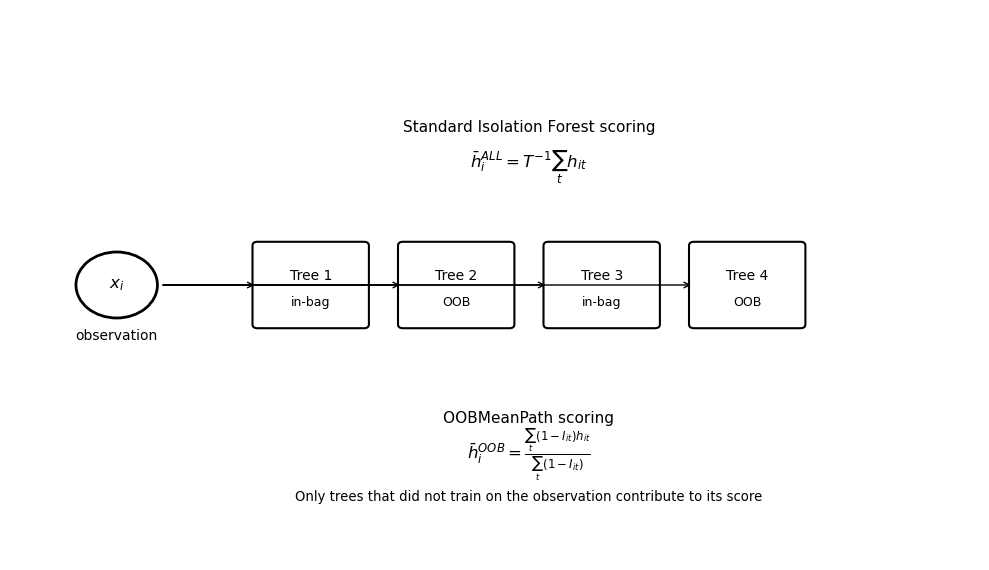

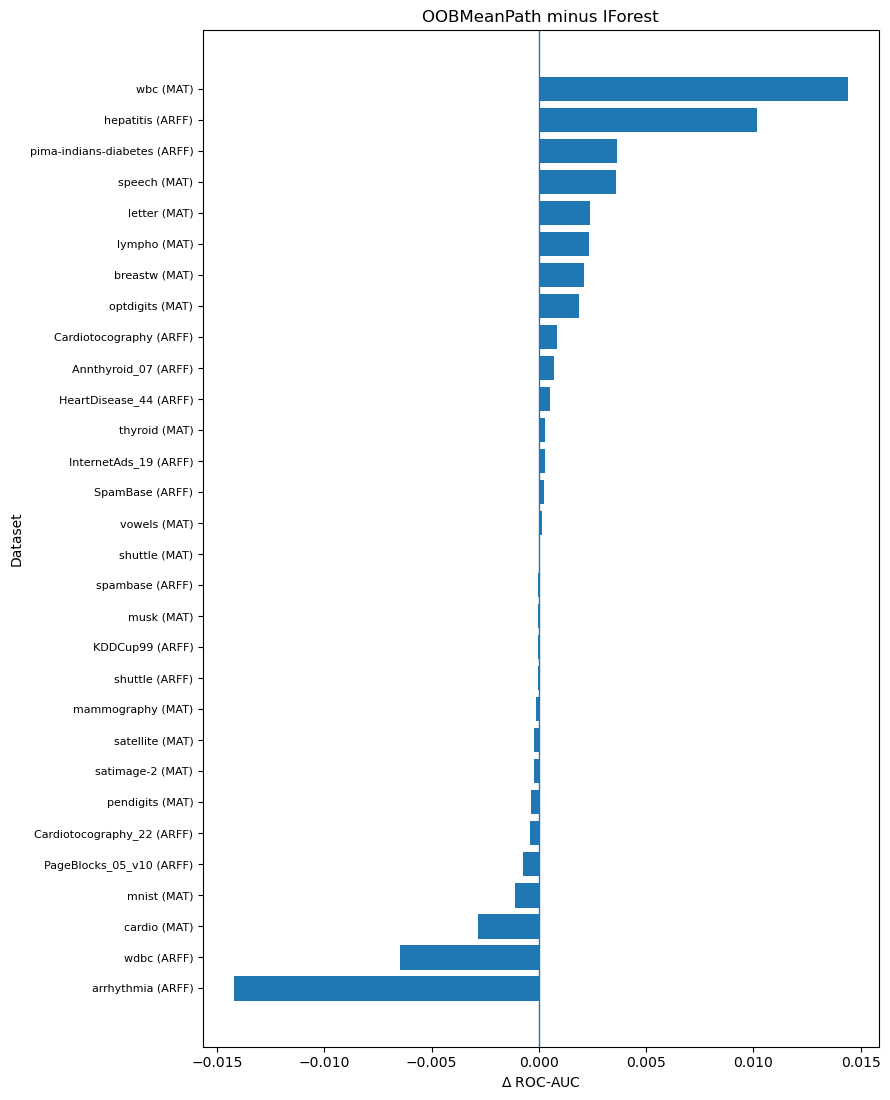

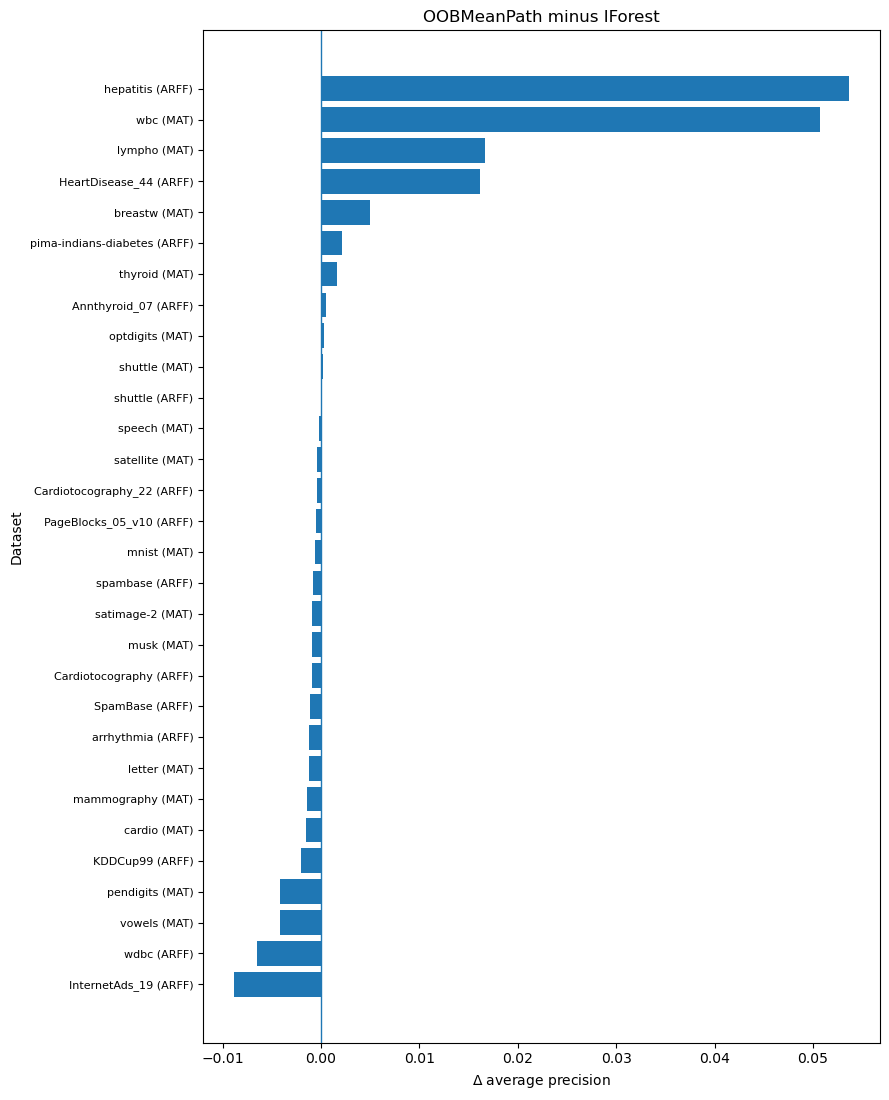

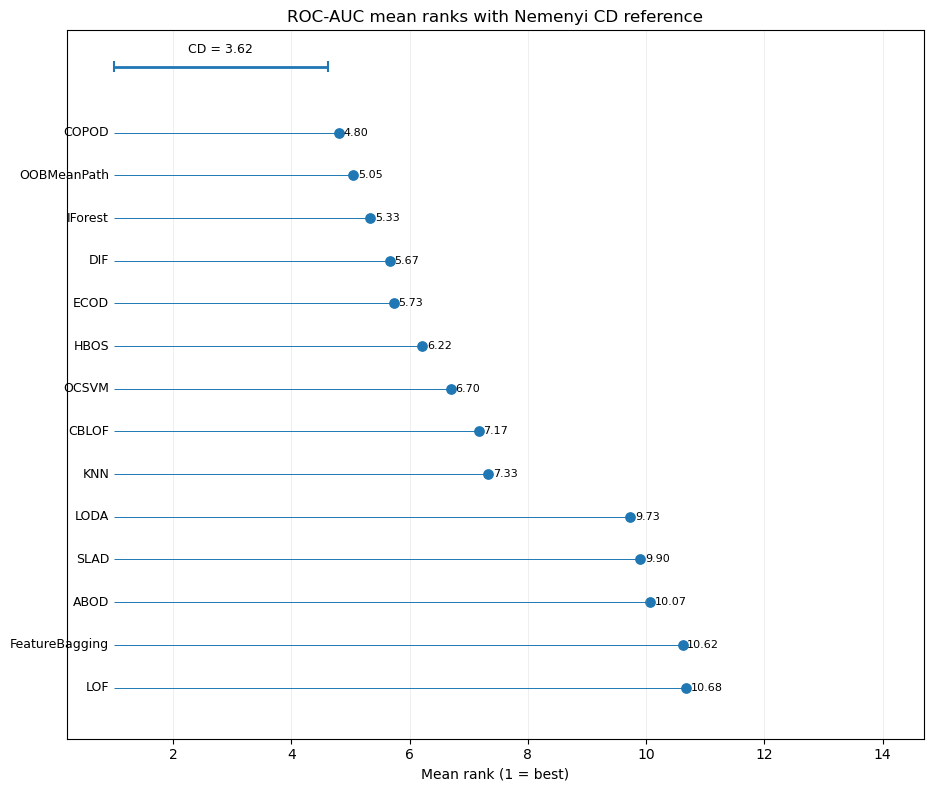

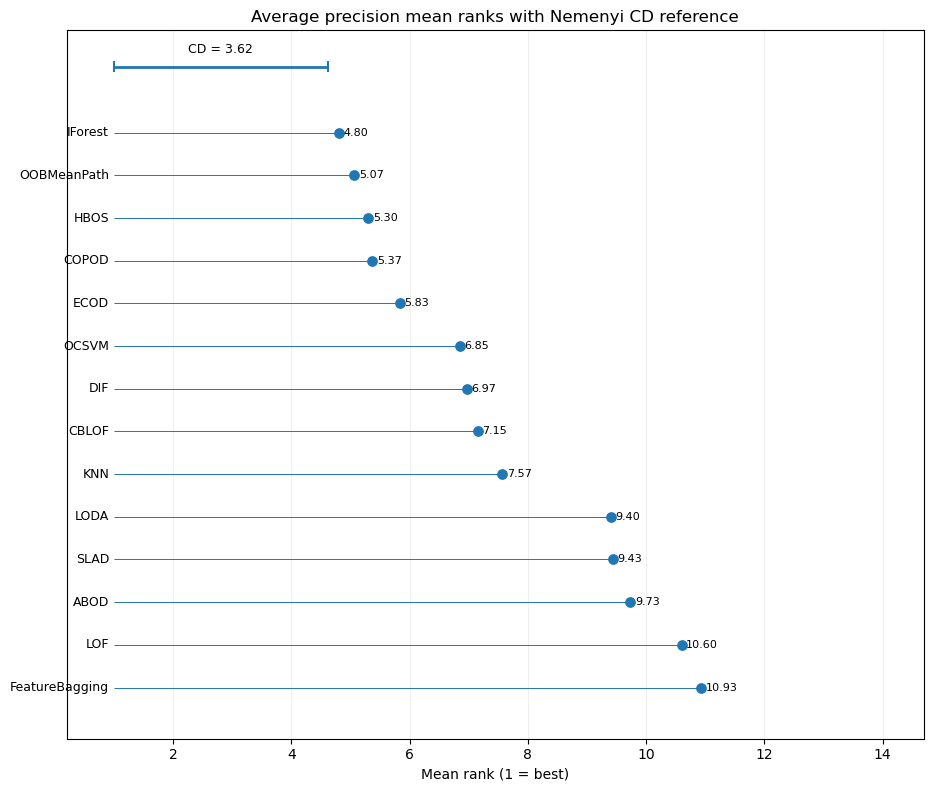

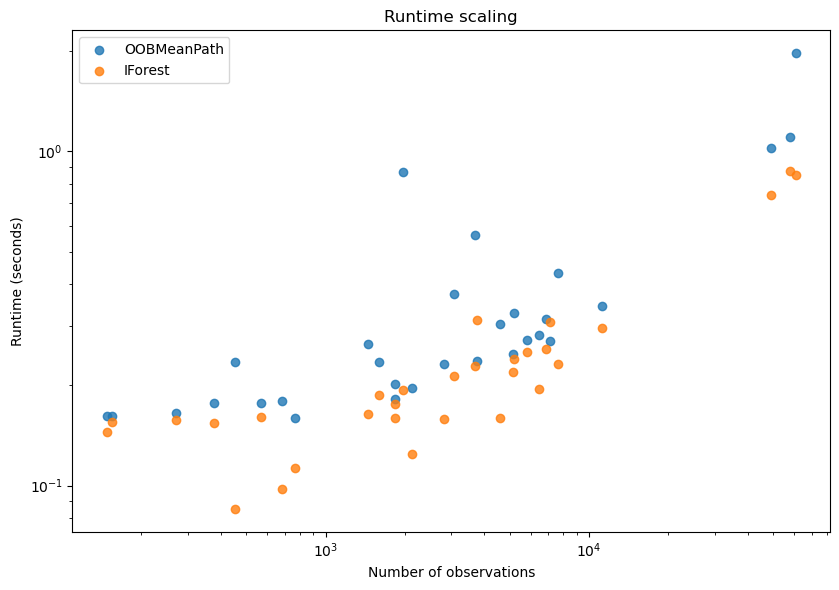

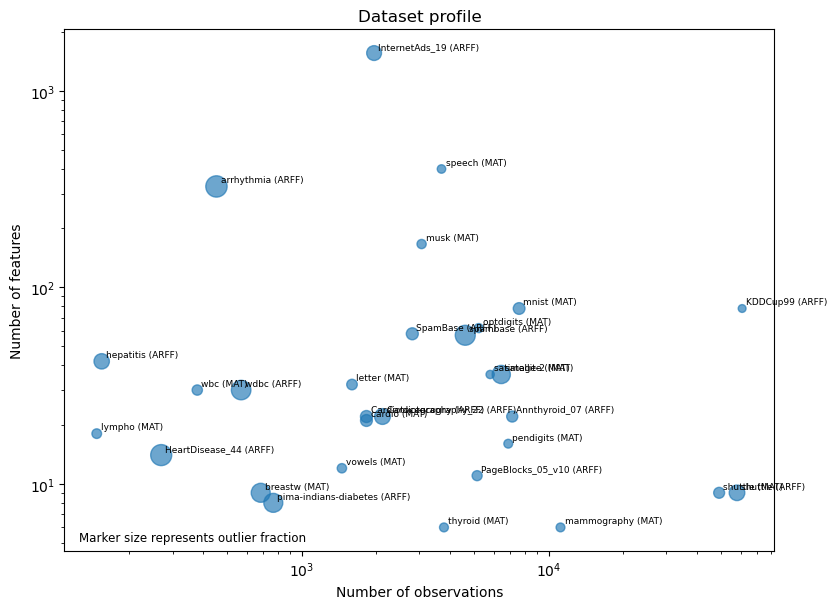

In [13]:

def save_figure(fig, stem):
  fig.tight_layout()

  fig.savefig(
    FIGURE_DIR / f"{stem}.png",
    dpi=300,
    bbox_inches="tight",
  )

  fig.savefig(
    FIGURE_DIR / f"{stem}.pdf",
    bbox_inches="tight",
  )

  plt.show()
  plt.close(fig)


def short_dataset_name(name):
  path = Path(name)
  stem = path.stem
  suffix = path.suffix.lower().replace(".", "").upper()

  for token in [
    "_withoutdupl_norm_10_v10",
    "_withoutdupl_norm_02_v10",
    "_withoutdupl_norm_v10",
    "_withoutdupl_norm",
    "_withoutdupl",
    "_original",
  ]:
    stem = stem.replace(
      token,
      "",
    )

  # Preserve the file type whenever two source files can share a name.
  return f"{stem} ({suffix})"


# OOBMeanPath scoring mechanism.
fig, ax = plt.subplots(
  figsize=(10, 5.8)
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis("off")

ax.add_patch(
  patches.Circle(
    (1.1, 3.5),
    0.42,
    fill=False,
    linewidth=2,
  )
)

ax.text(
  1.1,
  3.5,
  r"$x_i$",
  ha="center",
  va="center",
  fontsize=12,
)

ax.text(
  1.1,
  2.8,
  "observation",
  ha="center",
  fontsize=10,
)

tree_x = [3.1, 4.6, 6.1, 7.6]
tree_labels = ["Tree 1", "Tree 2", "Tree 3", "Tree 4"]
membership = ["in-bag", "OOB", "in-bag", "OOB"]

for x, label, member in zip(
  tree_x,
  tree_labels,
  membership,
):
  ax.add_patch(
    patches.FancyBboxPatch(
      (x - 0.55, 3.0),
      1.1,
      1.0,
      boxstyle="round,pad=0.05",
      fill=False,
      linewidth=1.5,
    )
  )

  ax.text(
    x,
    3.62,
    label,
    ha="center",
    va="center",
    fontsize=10,
  )

  ax.text(
    x,
    3.28,
    member,
    ha="center",
    va="center",
    fontsize=9,
  )

  ax.annotate(
    "",
    xy=(x - 0.55, 3.5),
    xytext=(1.55, 3.5),
    arrowprops=dict(
      arrowstyle="->",
      linewidth=1,
    ),
  )

ax.text(
  5.35,
  5.45,
  "Standard Isolation Forest scoring",
  ha="center",
  fontsize=11,
)

ax.text(
  5.35,
  5.0,
  r"$\bar h_i^{ALL}=T^{-1}\sum_t h_{it}$",
  ha="center",
  fontsize=12,
)

ax.text(
  5.35,
  1.75,
  "OOBMeanPath scoring",
  ha="center",
  fontsize=11,
)

ax.text(
  5.35,
  1.28,
  r"$\bar h_i^{OOB}"
  r"=\frac{\sum_t(1-I_{it})h_{it}}"
  r"{\sum_t(1-I_{it})}$",
  ha="center",
  fontsize=12,
)

ax.text(
  5.35,
  0.75,
  "Only trees that did not train on the observation "
  "contribute to its score",
  ha="center",
  fontsize=9.5,
)

save_figure(
  fig,
  "mechanism_OOBMeanPath",
)


def paired_difference_plot(
  df,
  metric,
  stem,
  x_label,
):
  W = (
    df
    .pivot(
      index="dataset",
      columns="method",
      values=metric,
    )[
      ["OOBMeanPath", "IForest"]
    ]
    .dropna()
  )

  W["difference"] = (
    W["OOBMeanPath"]
    - W["IForest"]
  )

  W = W.sort_values(
    "difference"
  )

  fig_height = max(
    7,
    0.32 * len(W) + 1.5,
  )

  fig, ax = plt.subplots(
    figsize=(9, fig_height)
  )

  y = np.arange(len(W))

  ax.barh(
    y,
    W["difference"].to_numpy(),
  )

  ax.axvline(
    0.0,
    linewidth=1,
  )

  ax.set_yticks(y)

  ax.set_yticklabels(
    [
      short_dataset_name(x)
      for x in W.index
    ],
    fontsize=8,
  )

  ax.set_xlabel(x_label)
  ax.set_ylabel("Dataset")
  ax.set_title(
    "OOBMeanPath minus IForest"
  )

  save_figure(
    fig,
    stem,
  )


paired_difference_plot(
  analysis_results,
  "ROC_AUC",
  "paired_difference_ROC_AUC",
  r"$\Delta$ ROC-AUC",
)

paired_difference_plot(
  analysis_results,
  "Average_Precision",
  "paired_difference_Average_Precision",
  r"$\Delta$ average precision",
)


def nemenyi_cd(
  n_methods,
  n_datasets,
  alpha=0.05,
):
  q = (
    studentized_range.ppf(
      1.0 - alpha,
      n_methods,
      np.inf,
    )
    / np.sqrt(2.0)
  )

  return float(
    q
    * np.sqrt(
      n_methods
      * (n_methods + 1)
      / (6.0 * n_datasets)
    )
  )


def critical_difference_rank_plot(
  rank_table,
  n_datasets,
  metric_label,
  stem,
  alpha=0.05,
):
  ranks_local = (
    rank_table[
      "mean_rank"
    ]
    .sort_values()
  )

  k = len(ranks_local)

  cd = nemenyi_cd(
    k,
    n_datasets,
    alpha=alpha,
  )

  fig, ax = plt.subplots(
    figsize=(
      9.5,
      max(
        6.5,
        0.43 * k + 2.0,
      ),
    )
  )

  y = np.arange(k)[::-1]
  x = ranks_local.to_numpy()

  ax.scatter(
    x,
    y,
    s=45,
  )

  for xi, yi, method in zip(
    x,
    y,
    ranks_local.index,
  ):
    ax.hlines(
      yi,
      1.0,
      xi,
      linewidth=0.7,
    )

    ax.text(
      0.92,
      yi,
      method,
      ha="right",
      va="center",
      fontsize=9,
    )

    ax.text(
      xi + 0.08,
      yi,
      f"{xi:.2f}",
      ha="left",
      va="center",
      fontsize=8,
    )

  ax.set_xlim(
    0.2,
    max(
      k + 0.7,
      float(x.max()) + 0.8,
    ),
  )

  ax.set_ylim(
    -1.2,
    k + 1.4,
  )

  ax.set_yticks([])
  ax.set_xlabel(
    "Mean rank (1 = best)"
  )
  ax.set_title(
    metric_label
  )

  y_cd = k + 0.55
  x0 = 1.0
  x1 = x0 + cd

  ax.hlines(
    y_cd,
    x0,
    x1,
    linewidth=2,
  )

  ax.vlines(
    [x0, x1],
    y_cd - 0.12,
    y_cd + 0.12,
    linewidth=1.5,
  )

  ax.text(
    (x0 + x1) / 2,
    y_cd + 0.25,
    f"CD = {cd:.2f}",
    ha="center",
    va="bottom",
    fontsize=9,
  )

  ax.grid(
    axis="x",
    linewidth=0.5,
    alpha=0.3,
  )

  save_figure(
    fig,
    stem,
  )


n_complete_roc = len(
  analysis_complete_matrices[
    "ROC_AUC"
  ]
)

n_complete_ap = len(
  analysis_complete_matrices[
    "Average_Precision"
  ]
)

critical_difference_rank_plot(
  analysis_rank_tables[
    "ROC_AUC"
  ],
  n_complete_roc,
  "ROC-AUC mean ranks with Nemenyi CD reference",
  "mean_rank_ROC_AUC",
)

critical_difference_rank_plot(
  analysis_rank_tables[
    "Average_Precision"
  ],
  n_complete_ap,
  "Average precision mean ranks with Nemenyi CD reference",
  "mean_rank_Average_Precision",
)


runtime_df = (
  analysis_results[
    analysis_results[
      "method"
    ].isin(
      [
        "OOBMeanPath",
        "IForest",
      ]
    )
  ][
    [
      "dataset",
      "n",
      "method",
      "runtime_sec",
    ]
  ]
  .dropna()
)

fig, ax = plt.subplots(
  figsize=(8.5, 6.0)
)

for method in [
  "OOBMeanPath",
  "IForest",
]:
  z = runtime_df[
    runtime_df[
      "method"
    ].eq(method)
  ]

  ax.scatter(
    z["n"],
    z["runtime_sec"],
    label=method,
    alpha=0.8,
  )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(
  "Number of observations"
)
ax.set_ylabel(
  "Runtime (seconds)"
)
ax.set_title(
  "Runtime scaling"
)
ax.legend()

save_figure(
  fig,
  "runtime_scaling_OOBMeanPath_IForest",
)


fig, ax = plt.subplots(
  figsize=(8.5, 6.2)
)

marker_sizes = (
  30.0
  + 450.0
  * analysis_meta[
    "outlier_fraction"
  ].to_numpy()
)

ax.scatter(
  analysis_meta["n"],
  analysis_meta["d"],
  s=marker_sizes,
  alpha=0.65,
)

for _, row in analysis_meta.iterrows():
  ax.annotate(
    short_dataset_name(
      row["dataset"]
    ),
    (
      row["n"],
      row["d"],
    ),
    xytext=(3, 3),
    textcoords="offset points",
    fontsize=6.5,
  )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(
  "Number of observations"
)
ax.set_ylabel(
  "Number of features"
)
ax.set_title(
  "Dataset profile"
)

ax.text(
  0.02,
  0.02,
  "Marker size represents outlier fraction",
  transform=ax.transAxes,
  fontsize=8.5,
)

save_figure(
  fig,
  "dataset_profile_n_d_outlier_fraction",
)


## Repeated matched-seed OOBMeanPath vs IForest analysis

For each repeat, OOBMeanPath and IForest use the same random seed on the same dataset. No seed is selected based on performance.



MATCHED-SEED 1/30: Annthyroid_withoutdupl_07.arff
 repeat 1/20
 repeat 2/20
 repeat 3/20
 repeat 4/20
 repeat 5/20
 repeat 6/20
 repeat 7/20
 repeat 8/20
 repeat 9/20
 repeat 10/20
 repeat 11/20
 repeat 12/20
 repeat 13/20
 repeat 14/20
 repeat 15/20
 repeat 16/20
 repeat 17/20
 repeat 18/20
 repeat 19/20
 repeat 20/20

MATCHED-SEED 2/30: arrhythmia.arff
 repeat 1/20
 repeat 2/20
 repeat 3/20
 repeat 4/20
 repeat 5/20
 repeat 6/20
 repeat 7/20
 repeat 8/20
 repeat 9/20
 repeat 10/20
 repeat 11/20
 repeat 12/20
 repeat 13/20
 repeat 14/20
 repeat 15/20
 repeat 16/20
 repeat 17/20
 repeat 18/20
 repeat 19/20
 repeat 20/20

MATCHED-SEED 3/30: breastw.mat
 repeat 1/20
 repeat 2/20
 repeat 3/20
 repeat 4/20
 repeat 5/20
 repeat 6/20
 repeat 7/20
 repeat 8/20
 repeat 9/20
 repeat 10/20
 repeat 11/20
 repeat 12/20
 repeat 13/20
 repeat 14/20
 repeat 15/20
 repeat 16/20
 repeat 17/20
 repeat 18/20
 repeat 19/20
 repeat 20/20

MATCHED-SEED 4/30: cardio.mat
 repeat 1/20
 repeat 2/20
 repeat 3/2

,dataset,OOBMeanPath_mean_ROC,OOBMeanPath_sd_ROC,IForest_mean_ROC,IForest_sd_ROC,mean_delta_ROC,sd_delta_ROC,OOBMeanPath_mean_AP,OOBMeanPath_sd_AP,IForest_mean_AP,IForest_sd_AP,mean_delta_AP,sd_delta_AP,OOBMeanPath_mean_runtime,IForest_mean_runtime,ROC_repeat_wins,AP_repeat_wins
0,Annthyroid_withoutdupl_07.arff,0.615920,0.020158,0.616047,0.020193,-0.000127,0.000561,0.114307,0.013580,0.114281,0.013528,0.000025,0.000548,0.278433,0.230271,9,11
1,Cardiotocography_22.arff,0.688818,0.025865,0.689578,0.026141,-0.000760,0.001460,0.436916,0.024274,0.437203,0.024377,-0.000288,0.001936,0.202927,0.180096,6,9
2,Cardiotocography_withoutdupl_norm_10_v10.arff,0.760653,0.027789,0.762312,0.027739,-0.001659,0.002004,0.332142,0.032886,0.334005,0.032972,-0.001863,0.003450,0.211269,0.187277,4,6
3,HeartDisease_withoutdupl_44.arff,0.615544,0.019549,0.621792,0.012989,-0.006247,0.017079,0.546907,0.019737,0.551093,0.013729,-0.004186,0.016411,0.164123,0.164841,7,8
4,InternetAds_withoutdupl_norm_19.arff,0.687540,0.020000,0.688508,0.019686,-0.000968,0.003161,0.462904,0.052017,0.473022,0.051355,-0.010118,0.004466,0.855509,0.195729,9,0
5,KDDCup99_original.arff,0.985739,0.002152,0.985797,0.002132,-0.000058,0.000037,0.383690,0.074123,0.386684,0.073832,-0.002993,0.001428,2.010920,0.755097,1,0
6,PageBlocks_withoutdupl_norm_05_v10.arff,0.904334,0.006529,0.904664,0.006471,-0.000330,0.000346,0.350747,0.020560,0.351868,0.020249,-0.001121,0.001112,0.262280,0.232678,3,4
7,SpamBase_withoutdupl_norm_10_v10.arff,0.823294,0.022599,0.824550,0.022194,-0.001256,0.001262,0.327655,0.041641,0.329341,0.041940,-0.001686,0.001741,0.211998,0.186878,2,3
8,arrhythmia.arff,0.736976,0.012136,0.745116,0.009399,-0.008140,0.010712,0.740235,0.013982,0.748748,0.010461,-0.008513,0.010265,0.173305,0.158408,4,4
9,breastw.mat,0.986049,0.001913,0.985611,0.002021,0.000439,0.000757,0.966885,0.005801,0.965667,0.006100,0.001218,0.002721,0.179623,0.168252,14,14


,repeat,seed,n_datasets,mean_OOBMeanPath_ROC,mean_IForest_ROC,mean_delta_ROC,mean_OOBMeanPath_AP,mean_IForest_AP,mean_delta_AP,ROC_wilcoxon_statistic,ROC_one_sided_p,AP_wilcoxon_statistic,AP_one_sided_p
0,1,20270813,30,0.805565,0.807616,-0.002051,0.489248,0.490009,-0.000761,112.0,0.994348,126.0,0.986886
1,2,20271810,30,0.798575,0.801007,-0.002432,0.480093,0.478424,0.001669,114.0,0.993583,139.0,0.973868
2,3,20272807,30,0.804905,0.806840,-0.001935,0.485002,0.488844,-0.003842,105.0,0.996444,128.0,0.985337
3,4,20273804,30,0.807450,0.809519,-0.002069,0.483450,0.486994,-0.003545,140.0,0.972539,130.0,0.983640
4,5,20274801,30,0.801286,0.803386,-0.002100,0.474653,0.482732,-0.008079,113.0,0.993976,84.0,0.999271
5,6,20275798,30,0.805384,0.808442,-0.003059,0.481139,0.485459,-0.004320,150.0,0.956031,214.0,0.649984
6,7,20276795,30,0.804122,0.804359,-0.000237,0.484424,0.484492,-0.000068,202.0,0.631248,195.0,0.780017
7,8,20277792,30,0.805308,0.806298,-0.000990,0.480400,0.484648,-0.004248,140.0,0.972539,182.0,0.850578
8,9,20278789,30,0.807907,0.807942,-0.000035,0.479272,0.485847,-0.006575,197.0,0.767727,159.0,0.935323
9,10,20279786,30,0.807549,0.808208,-0.000659,0.473277,0.479793,-0.006516,149.0,0.957967,164.0,0.921026


,metric,alternative,n_datasets,mean_delta,median_delta,wins,ties,losses,wilcoxon_statistic,one_sided_p,rank_biserial
0,ROC_AUC,OOBMeanPath > IForest,30,-0.001342,-0.000244,7,0,23,89.0,0.998906,-0.617204
1,Average_Precision,OOBMeanPath > IForest,30,-0.003772,-0.000581,9,0,21,122.0,0.989575,-0.475269


,metric,mean_of_repeat_mean_delta,sd_of_repeat_mean_delta,repeats_with_positive_mean_delta,repeats_with_one_sided_p_below_0_05
0,ROC_AUC,-0.001342,0.000918,1,0
1,Average_Precision,-0.003772,0.002913,2,0


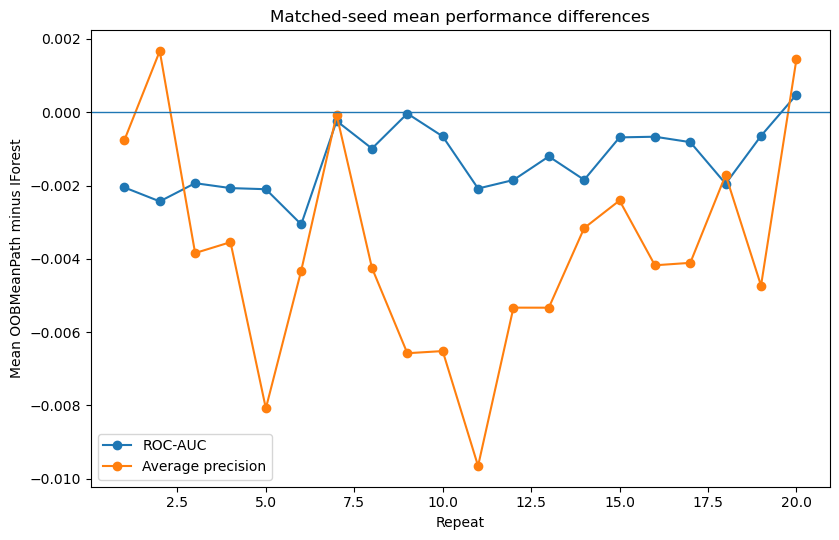

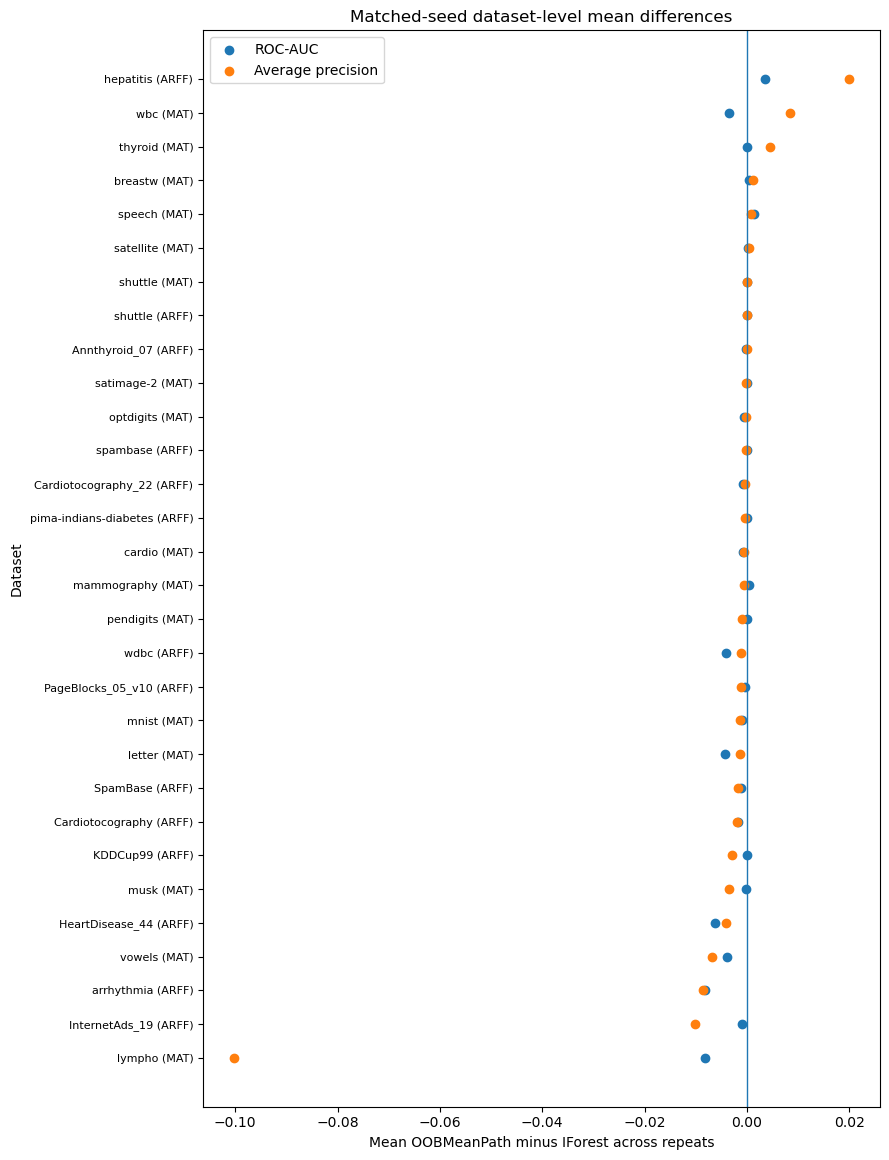

In [14]:
matched_rows = []
robustness_fails = []

total = len(
  DATASET_FILES
)

for j, p in enumerate(
  DATASET_FILES,
  start=1,
):
  print(
    "\n"
    + "=" * 78
  )

  print(
    f"MATCHED-SEED "
    f"{j}/{total}: "
    f"{p.name}",
    flush=True,
  )

  try:
    X, y = load_dataset(
      p
    )

    X = basic_clean(
      X
    )

    validate_dataset(
      X,
      y,
      p.name,
    )

    Z = (
      StandardScaler()
      .fit_transform(
        X
      )
    )

    n = len(
      X
    )

    for repeat, seed in enumerate(
      REPEAT_SEEDS,
      start=1,
    ):
      print(
        f" repeat "
        f"{repeat}/{N_REPEATS}",
        flush=True,
      )

      oob = fit_oob_once(
        Z,
        seed,
      )

      if_score, if_time = fit_iforest(
        Z,
        seed=seed,
      )

      oob_roc, oob_ap = evaluate(
        y,
        oob[
          "score"
        ],
      )

      if_roc, if_ap = evaluate(
        y,
        if_score,
      )

      matched_rows.append({
        "dataset": p.name,
        "repeat": repeat,
        "seed": seed,
        "n": n,
        "psi_oob": oob[
          "psi"
        ],
        "OOBMeanPath_ROC": oob_roc,
        "IForest_ROC": if_roc,
        "delta_ROC": (
          oob_roc
          - if_roc
        ),
        "OOBMeanPath_AP": oob_ap,
        "IForest_AP": if_ap,
        "delta_AP": (
          oob_ap
          - if_ap
        ),
        "OOBMeanPath_runtime_sec": oob[
          "runtime"
        ],
        "IForest_runtime_sec": if_time,
        "mean_oob_trees": float(
          oob[
            "oob_count"
          ].mean()
        ),
      })

      pd.DataFrame(
        matched_rows
      ).to_csv(
        OUTPUT_DIR
        / "matched_seed_checkpoint.csv",
        index=False,
        float_format="%.17g",
      )

  except Exception as e:
    robustness_fails.append({
      "dataset": p.name,
      "error": (
        f"{type(e).__name__}: {e}"
      ),
    })

    print(
      "[MATCHED-SEED FAILED]",
      robustness_fails[
        -1
      ],
    )


matched_seed_results = pd.DataFrame(
  matched_rows
)

robustness_failures = pd.DataFrame(
  robustness_fails
)

matched_seed_results.to_csv(
  OUTPUT_DIR
  / "matched_seed_results.csv",
  index=False,
  float_format="%.17g",
)

robustness_failures.to_csv(
  OUTPUT_DIR
  / "robustness_failures.csv",
  index=False,
)


if len(
  matched_seed_results
):
  dataset_seed_summary = (
    matched_seed_results
    .groupby(
      "dataset"
    )
    .agg(
      OOBMeanPath_mean_ROC=(
        "OOBMeanPath_ROC",
        "mean",
      ),
      OOBMeanPath_sd_ROC=(
        "OOBMeanPath_ROC",
        "std",
      ),
      IForest_mean_ROC=(
        "IForest_ROC",
        "mean",
      ),
      IForest_sd_ROC=(
        "IForest_ROC",
        "std",
      ),
      mean_delta_ROC=(
        "delta_ROC",
        "mean",
      ),
      sd_delta_ROC=(
        "delta_ROC",
        "std",
      ),
      OOBMeanPath_mean_AP=(
        "OOBMeanPath_AP",
        "mean",
      ),
      OOBMeanPath_sd_AP=(
        "OOBMeanPath_AP",
        "std",
      ),
      IForest_mean_AP=(
        "IForest_AP",
        "mean",
      ),
      IForest_sd_AP=(
        "IForest_AP",
        "std",
      ),
      mean_delta_AP=(
        "delta_AP",
        "mean",
      ),
      sd_delta_AP=(
        "delta_AP",
        "std",
      ),
      OOBMeanPath_mean_runtime=(
        "OOBMeanPath_runtime_sec",
        "mean",
      ),
      IForest_mean_runtime=(
        "IForest_runtime_sec",
        "mean",
      ),
    )
    .reset_index()
  )

  dataset_seed_summary[
    "ROC_repeat_wins"
  ] = (
    matched_seed_results
    .assign(
      win=lambda z:
      z[
        "delta_ROC"
      ] > 0
    )
    .groupby(
      "dataset"
    )[
      "win"
    ]
    .sum()
    .reindex(
      dataset_seed_summary[
        "dataset"
      ]
    )
    .to_numpy()
  )

  dataset_seed_summary[
    "AP_repeat_wins"
  ] = (
    matched_seed_results
    .assign(
      win=lambda z:
      z[
        "delta_AP"
      ] > 0
    )
    .groupby(
      "dataset"
    )[
      "win"
    ]
    .sum()
    .reindex(
      dataset_seed_summary[
        "dataset"
      ]
    )
    .to_numpy()
  )

  display(
    dataset_seed_summary
  )

  dataset_seed_summary.to_csv(
    OUTPUT_DIR
    / "matched_seed_dataset_summary.csv",
    index=False,
    float_format="%.17g",
  )


  repeat_rows = []

  for repeat, g in matched_seed_results.groupby(
    "repeat"
  ):
    row = {
      "repeat": int(
        repeat
      ),
      "seed": int(
        g[
          "seed"
        ].iloc[
          0
        ]
      ),
      "n_datasets": int(
        g[
          "dataset"
        ].nunique()
      ),
      "mean_OOBMeanPath_ROC": float(
        g[
          "OOBMeanPath_ROC"
        ].mean()
      ),
      "mean_IForest_ROC": float(
        g[
          "IForest_ROC"
        ].mean()
      ),
      "mean_delta_ROC": float(
        g[
          "delta_ROC"
        ].mean()
      ),
      "mean_OOBMeanPath_AP": float(
        g[
          "OOBMeanPath_AP"
        ].mean()
      ),
      "mean_IForest_AP": float(
        g[
          "IForest_AP"
        ].mean()
      ),
      "mean_delta_AP": float(
        g[
          "delta_AP"
        ].mean()
      ),
    }

    for metric, oob_col, if_col in [
      (
        "ROC",
        "OOBMeanPath_ROC",
        "IForest_ROC",
      ),
      (
        "AP",
        "OOBMeanPath_AP",
        "IForest_AP",
      ),
    ]:
      d = (
        g[
          oob_col
        ].to_numpy()
        - g[
          if_col
        ].to_numpy()
      )

      if np.all(
        np.isclose(
          d,
          0.0,
          atol=1e-12,
        )
      ):
        stat = 0.0
        p_value = 1.0
      else:
        stat, p_value = wilcoxon(
          g[
            oob_col
          ],
          g[
            if_col
          ],
          alternative="greater",
          zero_method="wilcox",
          method="auto",
        )

      row[
        f"{metric}_wilcoxon_statistic"
      ] = float(
        stat
      )

      row[
        f"{metric}_one_sided_p"
      ] = float(
        p_value
      )

    repeat_rows.append(
      row
    )


  matched_seed_by_repeat = pd.DataFrame(
    repeat_rows
  )

  display(
    matched_seed_by_repeat
  )

  matched_seed_by_repeat.to_csv(
    OUTPUT_DIR
    / "matched_seed_by_repeat.csv",
    index=False,
    float_format="%.17g",
  )


  mean_test_rows = []

  for metric, oob_col, if_col in [
    (
      "ROC_AUC",
      "OOBMeanPath_mean_ROC",
      "IForest_mean_ROC",
    ),
    (
      "Average_Precision",
      "OOBMeanPath_mean_AP",
      "IForest_mean_AP",
    ),
  ]:
    d = (
      dataset_seed_summary[
        oob_col
      ]
      - dataset_seed_summary[
        if_col
      ]
    )

    if np.all(
      np.isclose(
        d.to_numpy(),
        0.0,
        atol=1e-12,
      )
    ):
      stat = 0.0
      p_value = 1.0
    else:
      stat, p_value = wilcoxon(
        dataset_seed_summary[
          oob_col
        ],
        dataset_seed_summary[
          if_col
        ],
        alternative="greater",
        zero_method="wilcox",
        method="auto",
      )

    mean_test_rows.append({
      "metric": metric,
      "alternative": (
        "OOBMeanPath > IForest"
      ),
      "n_datasets": int(
        len(
          dataset_seed_summary
        )
      ),
      "mean_delta": float(
        d.mean()
      ),
      "median_delta": float(
        d.median()
      ),
      "wins": int(
        (
          d > 0
        ).sum()
      ),
      "ties": int(
        np.isclose(
          d,
          0.0,
          atol=1e-12,
        ).sum()
      ),
      "losses": int(
        (
          d < 0
        ).sum()
      ),
      "wilcoxon_statistic": float(
        stat
      ),
      "one_sided_p": float(
        p_value
      ),
      "rank_biserial": float(
        rank_biserial_from_differences(
          d
        )
      ),
    })


  matched_seed_mean_tests = pd.DataFrame(
    mean_test_rows
  )

  display(
    matched_seed_mean_tests
  )

  matched_seed_mean_tests.to_csv(
    OUTPUT_DIR
    / "matched_seed_mean_tests.csv",
    index=False,
    float_format="%.17g",
  )


  repeat_summary = pd.DataFrame({
    "metric": [
      "ROC_AUC",
      "Average_Precision",
    ],
    "mean_of_repeat_mean_delta": [
      matched_seed_by_repeat[
        "mean_delta_ROC"
      ].mean(),
      matched_seed_by_repeat[
        "mean_delta_AP"
      ].mean(),
    ],
    "sd_of_repeat_mean_delta": [
      matched_seed_by_repeat[
        "mean_delta_ROC"
      ].std(),
      matched_seed_by_repeat[
        "mean_delta_AP"
      ].std(),
    ],
    "repeats_with_positive_mean_delta": [
      int(
        (
          matched_seed_by_repeat[
            "mean_delta_ROC"
          ] > 0
        ).sum()
      ),
      int(
        (
          matched_seed_by_repeat[
            "mean_delta_AP"
          ] > 0
        ).sum()
      ),
    ],
    "repeats_with_one_sided_p_below_0_05": [
      int(
        (
          matched_seed_by_repeat[
            "ROC_one_sided_p"
          ] < 0.05
        ).sum()
      ),
      int(
        (
          matched_seed_by_repeat[
            "AP_one_sided_p"
          ] < 0.05
        ).sum()
      ),
    ],
  })

  display(
    repeat_summary
  )

  repeat_summary.to_csv(
    OUTPUT_DIR
    / "matched_seed_repeat_summary.csv",
    index=False,
    float_format="%.17g",
  )


  # Repeat-level mean differences.
  fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
  )

  ax.plot(
    matched_seed_by_repeat[
      "repeat"
    ],
    matched_seed_by_repeat[
      "mean_delta_ROC"
    ],
    marker="o",
    label="ROC-AUC",
  )

  ax.plot(
    matched_seed_by_repeat[
      "repeat"
    ],
    matched_seed_by_repeat[
      "mean_delta_AP"
    ],
    marker="o",
    label="Average precision",
  )

  ax.axhline(
    0.0,
    linewidth=1,
  )

  ax.set_xlabel(
    "Repeat"
  )

  ax.set_ylabel(
    "Mean OOBMeanPath minus IForest"
  )

  ax.set_title(
    "Matched-seed mean performance differences"
  )

  ax.legend()

  save_figure(
    fig,
    "matched_seed_mean_differences",
  )


  # Dataset-level mean differences across repeats.
  plot_df = (
    dataset_seed_summary
    .set_index(
      "dataset"
    )[
      [
        "mean_delta_ROC",
        "mean_delta_AP",
      ]
    ]
    .sort_values(
      "mean_delta_AP"
    )
  )

  fig_height = max(
    7,
    0.34
    * len(
      plot_df
    )
    + 1.5,
  )

  fig, ax = plt.subplots(
    figsize=(
      9,
      fig_height,
    )
  )

  y_pos = np.arange(
    len(
      plot_df
    )
  )

  ax.scatter(
    plot_df[
      "mean_delta_ROC"
    ],
    y_pos,
    label="ROC-AUC",
  )

  ax.scatter(
    plot_df[
      "mean_delta_AP"
    ],
    y_pos,
    label="Average precision",
  )

  ax.axvline(
    0.0,
    linewidth=1,
  )

  ax.set_yticks(
    y_pos
  )

  ax.set_yticklabels(
    [
      short_dataset_name(
        name
      )
      for name in plot_df.index
    ],
    fontsize=8,
  )

  ax.set_xlabel(
    "Mean OOBMeanPath minus IForest across repeats"
  )

  ax.set_ylabel(
    "Dataset"
  )

  ax.set_title(
    "Matched-seed dataset-level mean differences"
  )

  ax.legend()

  save_figure(
    fig,
    "matched_seed_dataset_mean_differences",
  )


## Leave-one-dataset-out sensitivity across all completed datasets


In [15]:

lodo = []

if RUN_BASELINES:
  completed_datasets = sorted(
    results[
      "dataset"
    ].unique()
  )

  for omit in completed_datasets:
    sub = results[
      results[
        "dataset"
      ].ne(
        omit
      )
    ]

    M = (
      sub
      .groupby(
        "method"
      )[
        [
          "ROC_AUC",
          "Average_Precision",
        ]
      ]
      .mean()
    )

    available_baselines = [
      b
      for b in BASELINES
      if b in M.index
    ]

    if (
      "OOBMeanPath"
      not in M.index
      or not available_baselines
    ):
      continue

    BB = M.loc[
      available_baselines
    ]

    br = BB[
      "ROC_AUC"
    ].idxmax()

    ba = BB[
      "Average_Precision"
    ].idxmax()

    lodo.append({
      "omitted_dataset": omit,
      "remaining_datasets": int(
        sub[
          "dataset"
        ].nunique()
      ),
      "OOB_ROC": float(
        M.loc[
          "OOBMeanPath",
          "ROC_AUC",
        ]
      ),
      "best_ROC_baseline": br,
      "best_baseline_ROC": float(
        BB.loc[
          br,
          "ROC_AUC",
        ]
      ),
      "delta_ROC": float(
        M.loc[
          "OOBMeanPath",
          "ROC_AUC",
        ]
        - BB.loc[
          br,
          "ROC_AUC",
        ]
      ),
      "OOB_AP": float(
        M.loc[
          "OOBMeanPath",
          "Average_Precision",
        ]
      ),
      "best_AP_baseline": ba,
      "best_baseline_AP": float(
        BB.loc[
          ba,
          "Average_Precision",
        ]
      ),
      "delta_AP": float(
        M.loc[
          "OOBMeanPath",
          "Average_Precision",
        ]
        - BB.loc[
          ba,
          "Average_Precision",
        ]
      ),
    })


lodo = pd.DataFrame(
  lodo
)

display(
  lodo
)

lodo.to_csv(
  OUTPUT_DIR
  / "leave_one_dataset_out.csv",
  index=False,
)


,omitted_dataset,remaining_datasets,OOB_ROC,best_ROC_baseline,best_baseline_ROC,delta_ROC,OOB_AP,best_AP_baseline,best_baseline_AP,delta_AP
0,Annthyroid_withoutdupl_07.arff,29,0.811980,IForest,0.811432,0.000548,0.494632,IForest,0.490900,0.003732
1,Cardiotocography_22.arff,29,0.810575,IForest,0.809989,0.000587,0.484322,IForest,0.480558,0.003764
2,Cardiotocography_withoutdupl_norm_10_v10.arff,29,0.807019,IForest,0.806475,0.000544,0.486454,HBOS,0.482958,0.003496
3,HeartDisease_withoutdupl_44.arff,29,0.813130,IForest,0.812574,0.000555,0.480304,IForest,0.477113,0.003191
4,InternetAds_withoutdupl_norm_19.arff,29,0.809772,IForest,0.809209,0.000563,0.483963,IForest,0.479909,0.004054
5,KDDCup99_original.arff,29,0.799711,IForest,0.799137,0.000574,0.490568,IForest,0.486749,0.003819
6,PageBlocks_withoutdupl_norm_05_v10.arff,29,0.802640,IForest,0.802041,0.000598,0.485585,HBOS,0.484125,0.001460
7,SpamBase_withoutdupl_norm_10_v10.arff,29,0.806724,IForest,0.806160,0.000564,0.490257,IForest,0.486469,0.003788
8,arrhythmia.arff,29,0.808308,IForest,0.807245,0.001063,0.473338,IForest,0.469548,0.003790
9,breastw.mat,29,0.799573,IForest,0.799073,0.000500,0.465437,IForest,0.461861,0.003576


In [16]:

proposed_found = set(
  results.loc[
    results[
      "role"
    ].eq(
      "PROPOSED"
    ),
    "method",
  ].unique()
)

assert proposed_found == {
  "OOBMeanPath"
}

print(
  "VERIFIED: OOBMeanPath is "
  "the only proposed method."
)

print(
  "VERIFIED: datasets were discovered automatically "
  "and preflight-validated."
)

print(
  "Discovered dataset files:",
  len(
    DATASET_FILES
  ),
)

print(
  "Successfully completed:",
  results[
    "dataset"
  ].nunique(),
)

print(
  "Main benchmark failures:",
  len(
    failures
  ),
)

print(
  "Preflight failures:",
  int((loader_audit["status"] != "OK").sum()),
)

print(
  "No fold or cross-fitting "
  "procedure is used."
)


print(
  "Matched-seed datasets completed:",
  (
    matched_seed_results[
      "dataset"
    ].nunique()
    if "matched_seed_results" in globals()
    and len(
      matched_seed_results
    )
    else 0
  ),
)

print(
  "Matched-seed failures:",
  (
    len(
      robustness_failures
    )
    if "robustness_failures" in globals()
    else 0
  ),
)

print(
  "\nOutput files:"
)

for p in sorted(
  OUTPUT_DIR.iterdir()
):
  if p.is_file():
    print(
      " -",
      p.name
    )


VERIFIED: OOBMeanPath is the only proposed method.
VERIFIED: datasets were discovered automatically and preflight-validated.
Discovered dataset files: 30
Successfully completed: 30
Main benchmark failures: 0
Preflight failures: 0
No fold or cross-fitting procedure is used.
Matched-seed datasets completed: 30
Matched-seed failures: 0

Output files:
 - _deep_baseline_worker.py
 - all_files_complete_14_method_results.csv
 - all_files_dataset_metadata.csv
 - all_files_friedman.csv
 - all_files_mean_performance.csv
 - all_files_mean_ranks_Average_Precision.csv
 - all_files_mean_ranks_combined.csv
 - all_files_mean_ranks_ROC_AUC.csv
 - all_files_one_sided_wilcoxon_OOB_vs_IForest.csv
 - bootstrap_ci.csv
 - dataset_level_performance_wide.csv
 - failures.csv
 - leave_one_dataset_out.csv
 - loader_audit.csv
 - main_method_results.csv
 - main_method_results_checkpoint.csv
 - matched_seed_by_repeat.csv
 - matched_seed_checkpoint.csv
 - matched_seed_dataset_summary.csv
 - matched_seed_mean_tests.cs